# 🏨 Hotel Booking Demand — Exploratory Data Analysis
### What drives cancellations and room rates in two Portuguese hotels?

| | |
|---|---|
| **Project title** | Exploratory Data Analysis of Hotel Booking Demand: Cancellation Behaviour and Pricing |
| **Student name** | Varun |
| **Course / Mentor** | AIML — EDA Minor Project · Mentor: Sruthi Tarimana |
| **Dataset** | Hotel Booking Demand (`hotel_bookings.csv`) |
| **Kaggle link** | https://www.kaggle.com/datasets/jessemostipak/hotel-booking-demand |
| **Original source** | Antonio, Almeida & Nunes (2019), *Hotel booking demand datasets*, Data in Brief 22 |

## 1. Project Introduction

**About the dataset.** Booking records from two real hotels in Portugal — a **City Hotel** (Lisbon) and a **Resort Hotel** (Algarve) — for stays arriving between **July 2015 and August 2017**. Each row is one reservation, described by 32 attributes: booking timing (`lead_time`, arrival date), stay details (nights, guests, meal plan, room type), customer and channel information (country, market segment, agent, customer type), history (previous cancellations, repeated guest), commercial terms (`deposit_type`, `adr` = average daily rate) and the outcome (`is_canceled`, `reservation_status`).

**Why it matters.** Cancellations are one of the biggest revenue risks in hospitality: a room cancelled late is a room that often stays empty. If a hotel can understand *which bookings are risky* and *what drives price*, it can plan overbooking, deposits and pricing more intelligently.

**Objective of the analysis.**
1. Assess and fix the **data quality** of the raw file (duplicates, hidden missing values, invalid records, outliers, target leakage).
2. Understand **who books, when, and how** (guest profile, channels, seasonality).
3. Identify the factors most associated with **cancellation** (`is_canceled`) and with **price** (`adr`).
4. Deliver a clean, documented dataset (`df_clean`) and judge how ready it is for a **future machine-learning project** (cancellation prediction / ADR regression).

## Workflow followed in this notebook
`Load → Understand → De-duplicate → Missing values → Clean & engineer → Categorical EDA → Numerical EDA → Outliers → Univariate → Bivariate → Multivariate → Insights → Conclusion (+ ML-readiness check)`

Every cleaning decision is recorded in a **cleaning log** (Section 6) so that the data pipeline is transparent and reproducible.

## 2. Load the Dataset

In [1]:
import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from IPython.display import display, Markdown

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook", palette="deep")
plt.rcParams.update({"figure.dpi": 100, "figure.figsize": (9, 5),
                     "axes.titleweight": "bold", "axes.titlesize": 13, "axes.labelsize": 11})
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)
pd.set_option("display.float_format", "{:,.2f}".format)

RANDOM_STATE = 42
cleaning_log = []

def log_step(step, before, after, reason):
    cleaning_log.append({"step": step, "rows_before": before, "rows_after": after,
                         "rows_removed": before - after, "reason": reason})

In [2]:
CANDIDATES = ["hotel_bookings.csv", "data/hotel_bookings.csv", "../input/hotel-booking-demand/hotel_bookings.csv"]
path = next((p for p in CANDIDATES if os.path.exists(p)), None)

if path is None:
    try:
        import kagglehub
        path = os.path.join(kagglehub.dataset_download("jessemostipak/hotel-booking-demand"), "hotel_bookings.csv")
    except Exception as err:
        raise FileNotFoundError("Place 'hotel_bookings.csv' next to this notebook "
                                "(download it from the Kaggle link in Section 1).") from err

df_raw = pd.read_csv(path)
df = df_raw.copy()
print(f"Loaded '{path}'  ->  {df.shape[0]:,} rows x {df.shape[1]} columns")

Loaded 'hotel_bookings.csv'  ->  119,390 rows x 32 columns


In [3]:
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,0.00,0,BB,PRT,Direct,Direct,0,0,0,C,C,3,No Deposit,NaN,NaN,0,Transient,0.00,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,0.00,0,BB,PRT,Direct,Direct,0,0,0,C,C,4,No Deposit,NaN,NaN,0,Transient,0.00,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,0.00,0,BB,GBR,Direct,Direct,0,0,0,A,C,0,No Deposit,NaN,NaN,0,Transient,75.00,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,0.00,0,BB,GBR,Corporate,Corporate,0,0,0,A,A,0,No Deposit,304.00,NaN,0,Transient,75.00,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,0.00,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,240.00,NaN,0,Transient,98.00,0,1,Check-Out,2015-07-03


In [4]:
df.tail()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
119385,City Hotel,0,23,2017,August,35,30,2,5,2,0.00,0,BB,BEL,Offline TA/TO,TA/TO,0,0,0,A,A,0,No Deposit,394.00,NaN,0,Transient,96.14,0,0,Check-Out,2017-09-06
119386,City Hotel,0,102,2017,August,35,31,2,5,3,0.00,0,BB,FRA,Online TA,TA/TO,0,0,0,E,E,0,No Deposit,9.00,NaN,0,Transient,225.43,0,2,Check-Out,2017-09-07
119387,City Hotel,0,34,2017,August,35,31,2,5,2,0.00,0,BB,DEU,Online TA,TA/TO,0,0,0,D,D,0,No Deposit,9.00,NaN,0,Transient,157.71,0,4,Check-Out,2017-09-07
119388,City Hotel,0,109,2017,August,35,31,2,5,2,0.00,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,89.00,NaN,0,Transient,104.40,0,0,Check-Out,2017-09-07
119389,City Hotel,0,205,2017,August,35,29,2,7,2,0.00,0,HB,DEU,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,9.00,NaN,0,Transient,151.20,0,2,Check-Out,2017-09-07


## 3. Understand the Dataset

In [5]:
print(f"Rows: {df.shape[0]:,}   Columns: {df.shape[1]}")
print(f"Memory usage: {df.memory_usage(deep=True).sum() / 1e6:.1f} MB")
print(f"Arrival period: {df['arrival_date_year'].min()} - {df['arrival_date_year'].max()}")
display(pd.DataFrame({"dtype": df.dtypes.astype(str), "non_null": df.notna().sum(), "n_unique": df.nunique()}))

Rows: 119,390   Columns: 32
Memory usage: 98.5 MB
Arrival period: 2015 - 2017


,dtype,non_null,n_unique
hotel,object,119390,2
is_canceled,int64,119390,2
lead_time,int64,119390,479
arrival_date_year,int64,119390,3
arrival_date_month,object,119390,12
arrival_date_week_number,int64,119390,53
arrival_date_day_of_month,int64,119390,31
stays_in_weekend_nights,int64,119390,17
stays_in_week_nights,int64,119390,35
adults,int64,119390,14


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

**Statistical summary — numerical columns**

In [7]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
is_canceled,"119,390.00",0.37,0.48,0.00,0.00,0.00,1.00,1.00
lead_time,"119,390.00",104.01,106.86,0.00,18.00,69.00,160.00,737.00
arrival_date_year,"119,390.00","2,016.16",0.71,"2,015.00","2,016.00","2,016.00","2,017.00","2,017.00"
arrival_date_week_number,"119,390.00",27.17,13.61,1.00,16.00,28.00,38.00,53.00
arrival_date_day_of_month,"119,390.00",15.80,8.78,1.00,8.00,16.00,23.00,31.00
stays_in_weekend_nights,"119,390.00",0.93,1.00,0.00,0.00,1.00,2.00,19.00
stays_in_week_nights,"119,390.00",2.50,1.91,0.00,1.00,2.00,3.00,50.00
adults,"119,390.00",1.86,0.58,0.00,2.00,2.00,2.00,55.00
children,"119,386.00",0.10,0.40,0.00,0.00,0.00,0.00,10.00
babies,"119,390.00",0.01,0.10,0.00,0.00,0.00,0.00,10.00


**Statistical summary — categorical columns**

In [8]:
df.describe(include=["object", "string"]).T

,count,unique,top,freq
hotel,119390,2,City Hotel,79330
arrival_date_month,119390,12,August,13877
meal,119390,5,BB,92310
country,118902,177,PRT,48590
market_segment,119390,8,Online TA,56477
distribution_channel,119390,5,TA/TO,97870
reserved_room_type,119390,10,A,85994
assigned_room_type,119390,12,A,74053
deposit_type,119390,3,No Deposit,104641
customer_type,119390,4,Transient,89613


**Unique values in each column** (all values shown when a column has ≤ 12 distinct values)

In [9]:
rows = []
for c in df.columns:
    u = df[c].dropna().unique()
    rows.append({"column": c, "n_unique": len(u),
                 "unique_values": sorted(map(str, u)) if len(u) <= 12 else f"{len(u)} distinct values  e.g. {list(map(str, u[:5]))}"})
pd.DataFrame(rows).set_index("column")

,n_unique,unique_values
column,,
hotel,2,"[City Hotel, Resort Hotel]"
is_canceled,2,"[0, 1]"
lead_time,479,"479 distinct values e.g. ['342', '737', '7', ..."
arrival_date_year,3,"[2015, 2016, 2017]"
arrival_date_month,12,"[April, August, December, February, January, J..."
arrival_date_week_number,53,"53 distinct values e.g. ['27', '28', '29', '3..."
arrival_date_day_of_month,31,"31 distinct values e.g. ['1', '2', '3', '4', ..."
stays_in_weekend_nights,17,"17 distinct values e.g. ['0', '1', '2', '4', ..."
stays_in_week_nights,35,"35 distinct values e.g. ['0', '1', '2', '3', ..."


In [10]:
print("Target variable `is_canceled` (raw data):")
display(df["is_canceled"].value_counts().to_frame("count").assign(percent=lambda t: t["count"] / t["count"].sum() * 100))

Target variable `is_canceled` (raw data):


,count,percent
is_canceled,,
0,75166,62.96
1,44224,37.04


**Observation:**
- The raw file has **119,390 rows × 32 columns**: 20 numeric and 12 text columns, covering two hotels (City Hotel and Resort Hotel) with arrivals from **2015 to 2017**.
- The target `is_canceled` is moderately imbalanced: **37.0% cancelled vs 63.0% not cancelled** in the raw data.
- Several columns have the **wrong or awkward type**: `children` and the ID columns `agent` / `company` are floats (because of missing values), `reservation_status_date` is plain text, and the arrival date is split across three columns.
- The summary statistics reveal suspicious values: a **negative** ADR (min −6.38), an ADR of **5,400**, **55 adults** in one booking and a `lead_time` of 737 days. The categorical summary reveals placeholders such as `Undefined` in `meal` and `distribution_channel`.
- `reservation_status` / `reservation_status_date` describe the *outcome* of a booking, so they are a data-leakage risk (confirmed in Section 6.4).

## 4. Check and Remove Duplicate Records

In [11]:
n_before = len(df)
n_dups = int(df.duplicated().sum())
cancel_rate_raw = df["is_canceled"].mean()

print(f"Duplicate rows found : {n_dups:,}  ({n_dups / n_before:.1%} of the data)")
dup_mask = df.duplicated(keep=False)
display(df[dup_mask].groupby("hotel")["is_canceled"].agg(rows="size", cancel_rate="mean"))
display(df[df.duplicated()].head(3))

Duplicate rows found : 31,994  (26.8% of the data)


,rows,cancel_rate
hotel,,
City Hotel,31748,0.61
Resort Hotel,8417,0.47


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
5,Resort Hotel,0,14,2015,July,27,1,0,2,2,0.00,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,240.00,NaN,0,Transient,98.00,0,1,Check-Out,2015-07-03
22,Resort Hotel,0,72,2015,July,27,1,2,4,2,0.00,0,BB,PRT,Direct,Direct,0,0,0,A,A,1,No Deposit,250.00,NaN,0,Transient,84.67,0,1,Check-Out,2015-07-07
43,Resort Hotel,0,70,2015,July,27,2,2,3,2,0.00,0,HB,ROU,Direct,Direct,0,0,0,E,E,0,No Deposit,250.00,NaN,0,Transient,137.00,0,1,Check-Out,2015-07-07


In [12]:
df = df.drop_duplicates().reset_index(drop=True)
log_step("Remove exact duplicate rows", n_before, len(df), "Identical on all 32 columns; the file has no booking ID, so repeats are treated as double-counted records")
cancel_rate_dedup = df["is_canceled"].mean()
n_after_dedup = len(df)

print(f"Rows before : {n_before:,}")
print(f"Rows after  : {len(df):,}   (removed {n_before - len(df):,})")
print(f"Cancellation rate  raw: {cancel_rate_raw:.1%}   ->   after de-duplication: {cancel_rate_dedup:.1%}")

Rows before : 119,390
Rows after  : 87,396   (removed 31,994)
Cancellation rate  raw: 37.0%   ->   after de-duplication: 27.5%


**Observation:** **31,994 rows (26.8%) were exact duplicates**, shrinking the data from **119,390 to 87,396** rows. They were not harmless: **63.1%** of the removed rows were cancellations, so removing them lowered the cancellation rate from **37.0% to 27.5%**. Duplicates were also concentrated in the City Hotel (about 61% cancelled among duplicated rows).

*Assumption to be aware of:* the file has no booking ID, so two rows identical in all 32 columns are treated as one repeated record. A few could be genuine separate bookings, but this is the standard treatment and the amount of distortion in the target justifies it.

## 5. Handle Missing Values

,missing_count,missing_%
company,82137,93.98
agent,12193,13.95
country,452,0.52
children,4,0.00


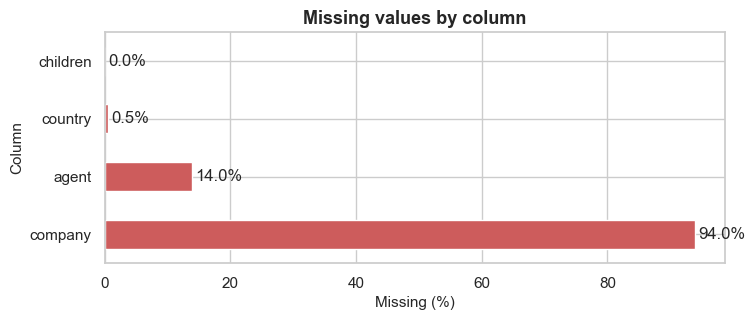

In [13]:
miss = df.isna().sum().to_frame("missing_count")
miss["missing_%"] = miss["missing_count"] / len(df) * 100
miss = miss[miss["missing_count"] > 0].sort_values("missing_count", ascending=False)
display(miss)

ax = miss["missing_%"].plot(kind="barh", color="indianred", figsize=(8, 3))
ax.set_title("Missing values by column"); ax.set_xlabel("Missing (%)"); ax.set_ylabel("Column")
for i, v in enumerate(miss["missing_%"]): ax.text(v + 0.5, i, f"{v:.1f}%", va="center")
plt.show()

**Decision per column** (the dataset documentation states that `NULL` in `agent` / `company` means *"not applicable"* — i.e. the booking was made without an agent or company):

| Column | Missing | Method | Reason |
|---|---|---|---|
| `company` | ~94% | Create flag `has_company`, then drop the ID column | Missing is meaningful (no company), and 94% sparsity with hundreds of IDs makes the raw ID useless |
| `agent` | ~14% | Create flag `has_agent`; fill missing ID with `"No Agent"` | Missing = booked directly; the agent ID is an identifier, not a number, so it is treated as a category |
| `country` | <1% | Fill with `"Unknown"` | Guest origin is genuinely unknown; inventing a country would add false information |
| `children` | 4 rows | Fill with `0` | Mode and median are both 0; with only 4 rows the effect is negligible |

In [14]:
df["has_company"] = df["company"].notna().astype(int)
df["has_agent"]   = df["agent"].notna().astype(int)
df["agent"]       = df["agent"].fillna(0).astype(int).astype(str).replace("0", "No Agent")
df["country"]     = df["country"].fillna("Unknown")
df["children"]    = df["children"].fillna(0)
df = df.drop(columns="company")

print("Missing values remaining:", int(df.isna().sum().sum()))
assert df.isna().sum().sum() == 0
display(df[["has_agent", "has_company", "agent", "country", "children"]].describe(include="all").T)

Missing values remaining: 0


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
has_agent,"87,396.00",NaN,NaN,NaN,0.86,0.35,0.00,1.00,1.00,1.00,1.00
has_company,"87,396.00",NaN,NaN,NaN,0.06,0.24,0.00,0.00,0.00,0.00,1.00
agent,87396,334,9,28759,NaN,NaN,NaN,NaN,NaN,NaN,NaN
country,87396,178,PRT,27453,NaN,NaN,NaN,NaN,NaN,NaN,NaN
children,"87,396.00",NaN,NaN,NaN,0.14,0.46,0.00,0.00,0.00,0.00,10.00


In [15]:
log_step("Impute / flag missing values", len(df), len(df), "company -> flag + drop; agent -> flag + 'No Agent'; country -> 'Unknown'; children -> 0 (no rows removed)")

**Observation:** Only four columns had missing values, and all are now handled (**0 missing values remain**).
- `company` (94% missing) and `agent` (14% missing) are missing because *no company / agent was involved*, so the missingness itself became the features `has_company` and `has_agent` — more informative than any imputed ID.
- `country` (0.5%) became an explicit `"Unknown"` category and the 4 missing `children` values were set to 0.
- Imputing the mean or mode for the ID columns would have invented relationships that do not exist, so it was deliberately avoided.

## 6. Clean the Dataset

### 6.1 Remove extra spaces and fix inconsistent / placeholder categories

In [16]:
text_cols = df.select_dtypes(include=["object", "string"]).columns
for c in text_cols:
    df[c] = df[c].astype(str).str.strip()

print("Before ->", "meal:", df["meal"].value_counts().to_dict())
print("          market_segment 'Undefined':", (df["market_segment"] == "Undefined").sum(),
      "| distribution_channel 'Undefined':", (df["distribution_channel"] == "Undefined").sum())
print("          country codes for China:", df["country"].isin(["CN", "CHN"]).groupby(df["country"]).sum().loc[["CN", "CHN"]].to_dict())

df["meal"] = df["meal"].replace({"Undefined": "SC"})

df[["market_segment", "distribution_channel"]] = df[["market_segment", "distribution_channel"]].replace({"Undefined": "Unknown"})

df["country"] = df["country"].replace({"CN": "CHN"})

print("After  ->", "meal:", df["meal"].value_counts().to_dict())
print("          country codes for China:", (df["country"] == "CHN").sum(), "rows under 'CHN'")

Before -> meal: {'BB': 67978, 'SC': 9481, 'HB': 9085, 'Undefined': 492, 'FB': 360}
          market_segment 'Undefined': 2 | distribution_channel 'Undefined': 5
          country codes for China: {'CN': 1093, 'CHN': 816}
After  -> meal: {'BB': 67978, 'SC': 9973, 'HB': 9085, 'FB': 360}
          country codes for China: 1909 rows under 'CHN'


### 6.2 Correct data types

In [17]:
MONTHS = ["January", "February", "March", "April", "May", "June", "July", "August",
          "September", "October", "November", "December"]
month_num = {m: i + 1 for i, m in enumerate(MONTHS)}

df["children"] = df["children"].astype(int)
df["arrival_date"] = pd.to_datetime(dict(year=df["arrival_date_year"],
                                         month=df["arrival_date_month"].map(month_num),
                                         day=df["arrival_date_day_of_month"]))
df["reservation_status_date"] = pd.to_datetime(df["reservation_status_date"])
df["arrival_date_month"] = pd.Categorical(df["arrival_date_month"], categories=MONTHS, ordered=True)

display(df[["children", "agent", "arrival_date", "reservation_status_date", "arrival_date_month"]].dtypes.to_frame("dtype"))

,dtype
children,int64
agent,object
arrival_date,datetime64[ns]
reservation_status_date,datetime64[ns]
arrival_date_month,category


### 6.3 Handle invalid values

In [18]:
total_guests_tmp = df["adults"] + df["children"] + df["babies"]
checks = pd.Series({
    "Booking with zero guests (adults+children+babies = 0)": int((total_guests_tmp == 0).sum()),
    "Negative ADR (price per night < 0)": int((df["adr"] < 0).sum()),
    "ADR = 0 (free / complimentary stay)": int((df["adr"] == 0).sum()),
    "Zero-night stay (0 weekend + 0 week nights)": int(((df["stays_in_week_nights"] + df["stays_in_weekend_nights"]) == 0).sum()),
}, name="rows")
display(checks.to_frame())
display(pd.crosstab(df["adr"] == 0, df["market_segment"]).T.rename(columns={False: "adr > 0", True: "adr = 0"}))

,rows
Booking with zero guests (adults+children+babies = 0),166
Negative ADR (price per night < 0),1
ADR = 0 (free / complimentary stay),1778
Zero-night stay (0 weekend + 0 week nights),651


adr,adr > 0,adr = 0
market_segment,,
Aviation,222,5
Complementary,62,640
Corporate,4138,74
Direct,11577,227
Groups,4722,220
Offline TA/TO,13629,260
Online TA,51266,352
Unknown,2,0


**Decisions**
- **Zero guests** and **negative ADR** are impossible values → rows removed.
- **ADR = 0** is *not* removed: it is concentrated in complimentary / corporate / direct bookings (see table), i.e. real free stays. These rows are kept, but price analysis in later sections uses `adr > 0`.
- **Zero-night stays** are kept (possible day-use or same-day check-out); they are a small share and carry genuine cancellation information.

In [19]:
n0 = len(df)
invalid = ((df["adults"] + df["children"] + df["babies"]) == 0) | (df["adr"] < 0)
df = df.loc[~invalid].reset_index(drop=True)
log_step("Remove invalid bookings", n0, len(df), "Zero guests or negative ADR are impossible values")
print(f"Removed {n0 - len(df):,} invalid rows  ->  {len(df):,} rows remain")

Removed 167 invalid rows  ->  87,229 rows remain


### 6.4 Detect and remove target leakage

`reservation_status` ("Canceled", "Check-Out", "No-Show") and `reservation_status_date` are recorded **after** the outcome is known. If they stay in the data, any model would simply read the answer instead of learning from booking information. Let us prove this before removing them.

In [20]:
display(pd.crosstab(df["reservation_status"], df["is_canceled"], margins=True))

canceled = df["reservation_status"] == "Canceled"
df["cancel_notice_days"] = np.where(canceled, (df["arrival_date"] - df["reservation_status_date"]).dt.days, np.nan)

df = df.drop(columns=["reservation_status", "reservation_status_date"])
print("Dropped leakage columns: reservation_status, reservation_status_date")

is_canceled,0,1,All
reservation_status,,,
Canceled,0,22996,22996
Check-Out,63220,0,63220
No-Show,0,1013,1013
All,63220,24009,87229


Dropped leakage columns: reservation_status, reservation_status_date


### 6.5 Feature engineering (simple, interpretable)

In [21]:
df["total_nights"] = df["stays_in_weekend_nights"] + df["stays_in_week_nights"]
df["total_guests"] = df["adults"] + df["children"] + df["babies"]
df["has_kids"]     = ((df["children"] + df["babies"]) > 0).astype(int)
df["room_mismatch"] = (df["reserved_room_type"] != df["assigned_room_type"]).astype(int)

top_countries = df["country"].value_counts().drop("Unknown", errors="ignore").head(15).index
df["country_grouped"] = np.where(df["country"].isin(top_countries), df["country"],
                                 np.where(df["country"] == "Unknown", "Unknown", "Other"))
top_agents = df.loc[df["agent"] != "No Agent", "agent"].value_counts().head(10).index
df["agent_grouped"] = np.where(df["agent"].isin(top_agents), "Agent " + df["agent"],
                               np.where(df["agent"] == "No Agent", "No Agent", "Other Agents"))
df = df.drop(columns="agent")

display(df[["total_nights", "total_guests", "has_kids", "room_mismatch", "country_grouped", "agent_grouped"]].head())
print(f"country: {df['country'].nunique()} codes -> {df['country_grouped'].nunique()} groups | agent: top 10 kept + 'Other Agents' + 'No Agent'")

,total_nights,total_guests,has_kids,room_mismatch,country_grouped,agent_grouped
0,0,2,0,0,PRT,No Agent
1,0,2,0,0,PRT,No Agent
2,1,1,0,1,GBR,No Agent
3,1,1,0,0,GBR,Other Agents
4,2,2,0,0,GBR,Agent 240


country: 177 codes -> 17 groups | agent: top 10 kept + 'Other Agents' + 'No Agent'


### 6.6 Cleaning log

In [22]:
log_step("Current shape after cleaning stage", len(df), len(df), f"{df.shape[1]} columns")
display(pd.DataFrame(cleaning_log).set_index("step"))

,rows_before,rows_after,rows_removed,reason
step,,,,
Remove exact duplicate rows,119390,87396,31994,Identical on all 32 columns; the file has no b...
Impute / flag missing values,87396,87396,0,company -> flag + drop; agent -> flag + 'No Ag...
Remove invalid bookings,87396,87229,167,Zero guests or negative ADR are impossible values
Current shape after cleaning stage,87229,87229,0,38 columns


**Observation:**
- **Hidden problems** that `isna()` cannot see were fixed: `meal = Undefined` (492 rows) is documented as identical to `SC` (no meal package), `Undefined` market segment / channel became `Unknown`, and the country code `CN` (1,093 rows) and `CHN` (816 rows) were merged into one spelling.
- **Impossible records** were removed: 166 bookings with zero guests and 1 negative-ADR row (167 in total). ADR = 0 rows were kept because they are mostly genuine complimentary stays (640 of roughly 700 Complementary bookings).
- **Leakage proven:** the cross-tab shows `reservation_status` and `is_canceled` match perfectly (Canceled / No-Show → 1, Check-Out → 0), so both status columns were dropped.
- The cleaning log shows the full row flow: 119,390 → 87,396 (duplicates) → **87,229** (invalid bookings).

## 7. Analyze Categorical Columns

In [23]:
cat_cols = ["hotel", "market_segment", "distribution_channel", "customer_type", "deposit_type", "meal",
            "reserved_room_type", "country_grouped", "agent_grouped", "arrival_date_month"]
for c in cat_cols[:6]:
    t = df[c].value_counts().to_frame("count"); t["percent"] = t["count"] / len(df) * 100
    print(f"\n{c}  ({df[c].nunique()} categories)"); display(t)


hotel  (2 categories)


,count,percent
hotel,,
City Hotel,53274,61.07
Resort Hotel,33955,38.93



market_segment  (8 categories)


,count,percent
market_segment,,
Online TA,51553,59.10
Offline TA/TO,13855,15.88
Direct,11780,13.50
Groups,4921,5.64
Corporate,4200,4.81
Complementary,692,0.79
Aviation,226,0.26
Unknown,2,0.00



distribution_channel  (5 categories)


...

,count,percent
customer_type,,
Transient,71862,82.38
Transient-Party,11691,13.40
Contract,3135,3.59
Group,541,0.62



deposit_type  (3 categories)


,count,percent
deposit_type,,
No Deposit,86084,98.69
Non Refund,1038,1.19
Refundable,107,0.12



meal  (4 categories)


,count,percent
meal,,
BB,67906,77.85
SC,9883,11.33
HB,9080,10.41
FB,360,0.41


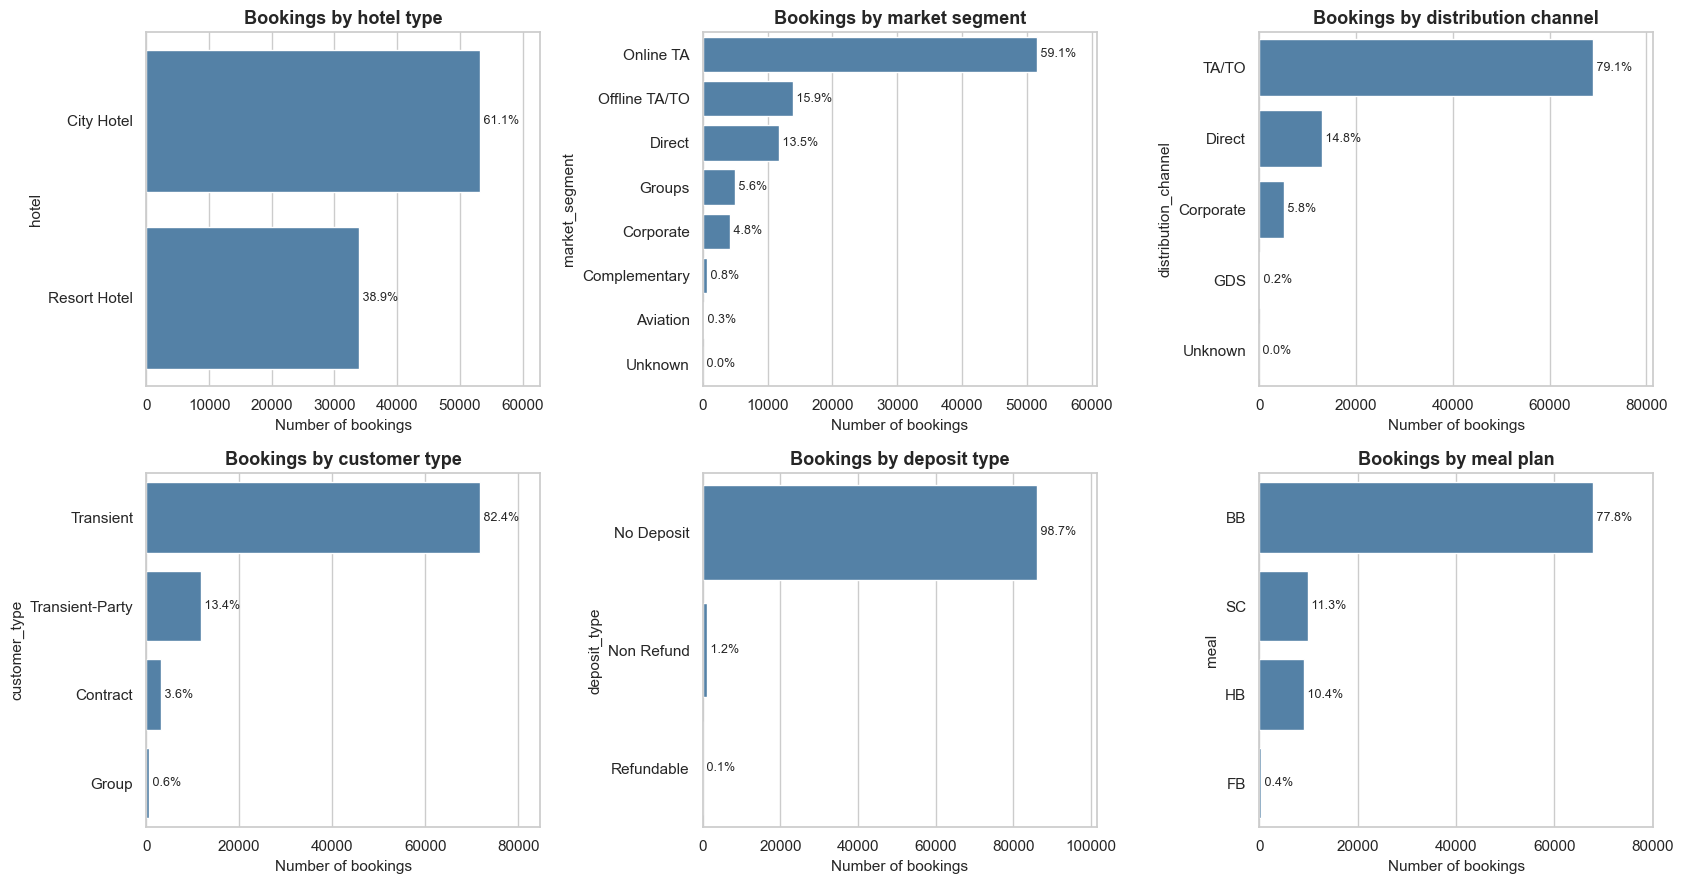

In [24]:
def count_plot(ax, col, title, top=None, order=None):
    s = df[col].value_counts()
    if top: s = s.head(top)
    if order is not None: s = s.reindex(order)
    sns.barplot(x=s.values, y=s.index.astype(str), ax=ax, color="steelblue")
    ax.set_title(title); ax.set_xlabel("Number of bookings"); ax.set_ylabel(col)
    for i, v in enumerate(s.values): ax.text(v, i, f" {v/len(df):.1%}", va="center", fontsize=9)
    ax.set_xlim(0, s.max() * 1.18)

fig, axes = plt.subplots(2, 3, figsize=(17, 9))
for ax, (c, t) in zip(axes.ravel(), [("hotel", "Bookings by hotel type"), ("market_segment", "Bookings by market segment"),
        ("distribution_channel", "Bookings by distribution channel"), ("customer_type", "Bookings by customer type"),
        ("deposit_type", "Bookings by deposit type"), ("meal", "Bookings by meal plan")]):
    count_plot(ax, c, t)
plt.tight_layout(); plt.show()

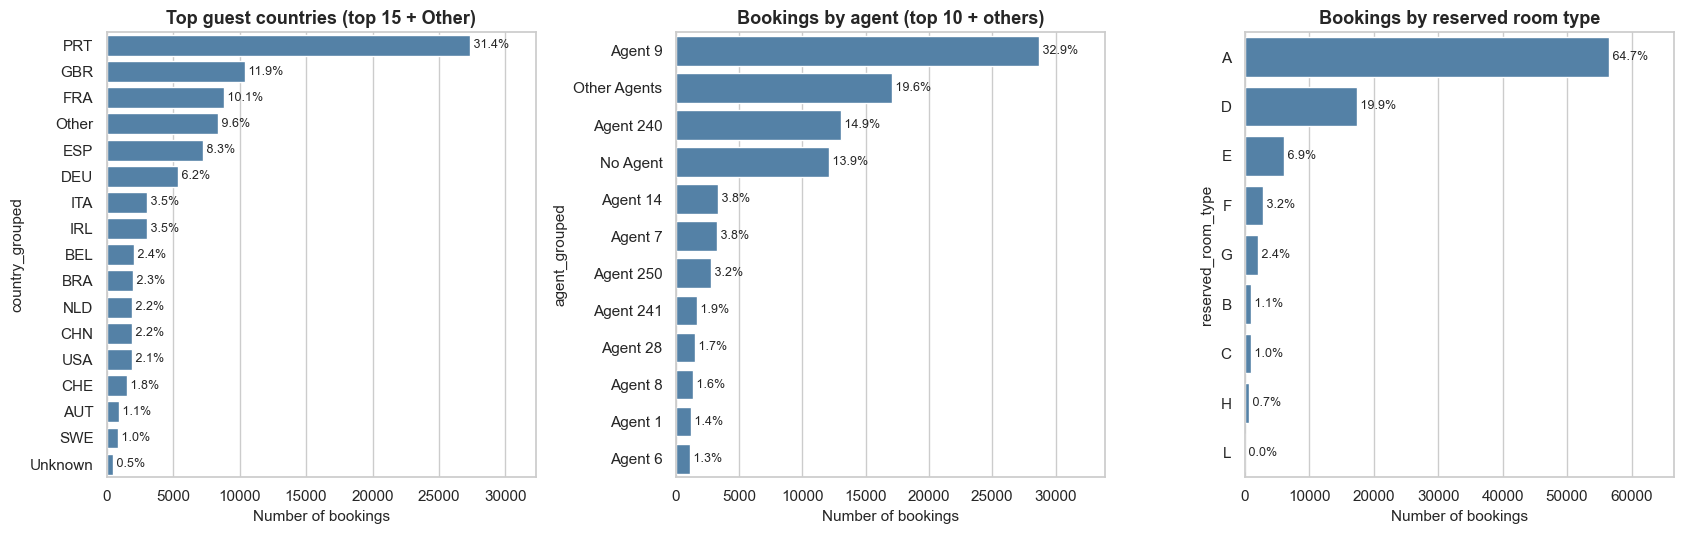

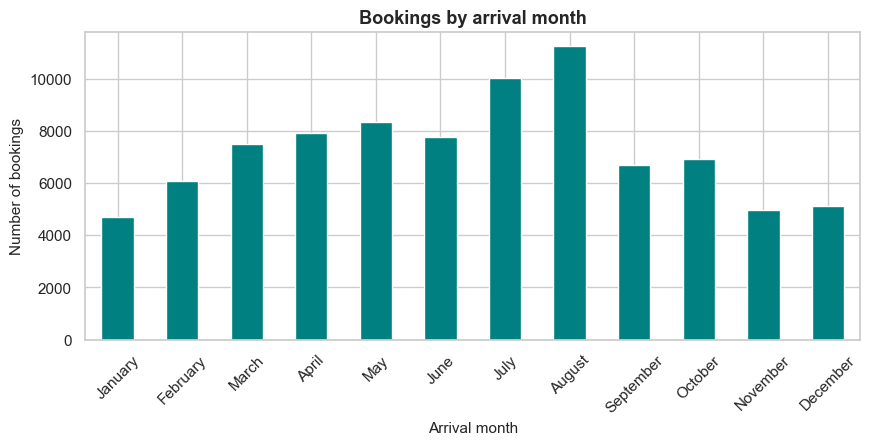

In [25]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5.5))
count_plot(axes[0], "country_grouped", "Top guest countries (top 15 + Other)")
count_plot(axes[1], "agent_grouped", "Bookings by agent (top 10 + others)")
count_plot(axes[2], "reserved_room_type", "Bookings by reserved room type")
plt.tight_layout(); plt.show()

m = df["arrival_date_month"].value_counts().reindex(MONTHS)
ax = m.plot(kind="bar", figsize=(10, 4), color="teal"); ax.set_title("Bookings by arrival month")
ax.set_xlabel("Arrival month"); ax.set_ylabel("Number of bookings"); plt.xticks(rotation=45); plt.show()

**Observation:**
- **Hotel:** the City Hotel holds about **61%** of bookings and the Resort Hotel about 39%.
- **Channels:** **59% of bookings come from Online Travel Agents** and 79% pass through the TA/TO channel; direct bookings are only ~13.5%. The business is heavily dependent on intermediaries.
- **Customers:** **82% are Transient** guests; Contract and Group customers are tiny groups (4% and 0.6%).
- **Terms:** **98.7% of bookings have no deposit**, and the dominant meal plan is Bed & Breakfast (78%).
- **Origin:** Portugal supplies about **31%** of guests, followed by the UK, France, Spain and Germany; a single agent (ID 9) handles about a third of all bookings.
- **Seasonality:** August, July and May are the busiest arrival months; November, December and January are the quietest.
- Several categories (Aviation, Refundable, GDS, Unknown) are very small — an important fact for modelling, because rare categories give unstable estimates.

## 8. Analyze Numerical Columns

In [26]:
num_cols = ["lead_time", "adr", "total_nights", "total_guests", "adults", "children", "babies", "booking_changes",
            "days_in_waiting_list", "previous_cancellations", "previous_bookings_not_canceled",
            "required_car_parking_spaces", "total_of_special_requests"]
summary = df[num_cols].agg(["count", "mean", "median", "min", "max", "std", "skew"]).T
summary["IQR"] = df[num_cols].quantile(.75) - df[num_cols].quantile(.25)
summary

,count,mean,median,min,max,std,skew,IQR
lead_time,"87,229.00",79.97,49.00,0.00,737.00,86.06,1.43,114.00
adr,"87,229.00",106.52,98.20,0.00,"5,400.00",54.89,11.02,61.85
total_nights,"87,229.00",3.63,3.00,0.00,69.00,2.74,2.95,3.00
total_guests,"87,229.00",2.03,2.00,1.00,55.00,0.79,10.54,0.00
adults,"87,229.00",1.88,2.00,0.00,55.00,0.62,20.39,0.00
children,"87,229.00",0.14,0.00,0.00,10.00,0.46,3.46,0.00
babies,"87,229.00",0.01,0.00,0.00,10.00,0.11,21.13,0.00
booking_changes,"87,229.00",0.27,0.00,0.00,18.00,0.71,5.07,0.00
days_in_waiting_list,"87,229.00",0.75,0.00,0.00,391.00,10.00,19.47,0.00
previous_cancellations,"87,229.00",0.03,0.00,0.00,26.00,0.37,34.33,0.00


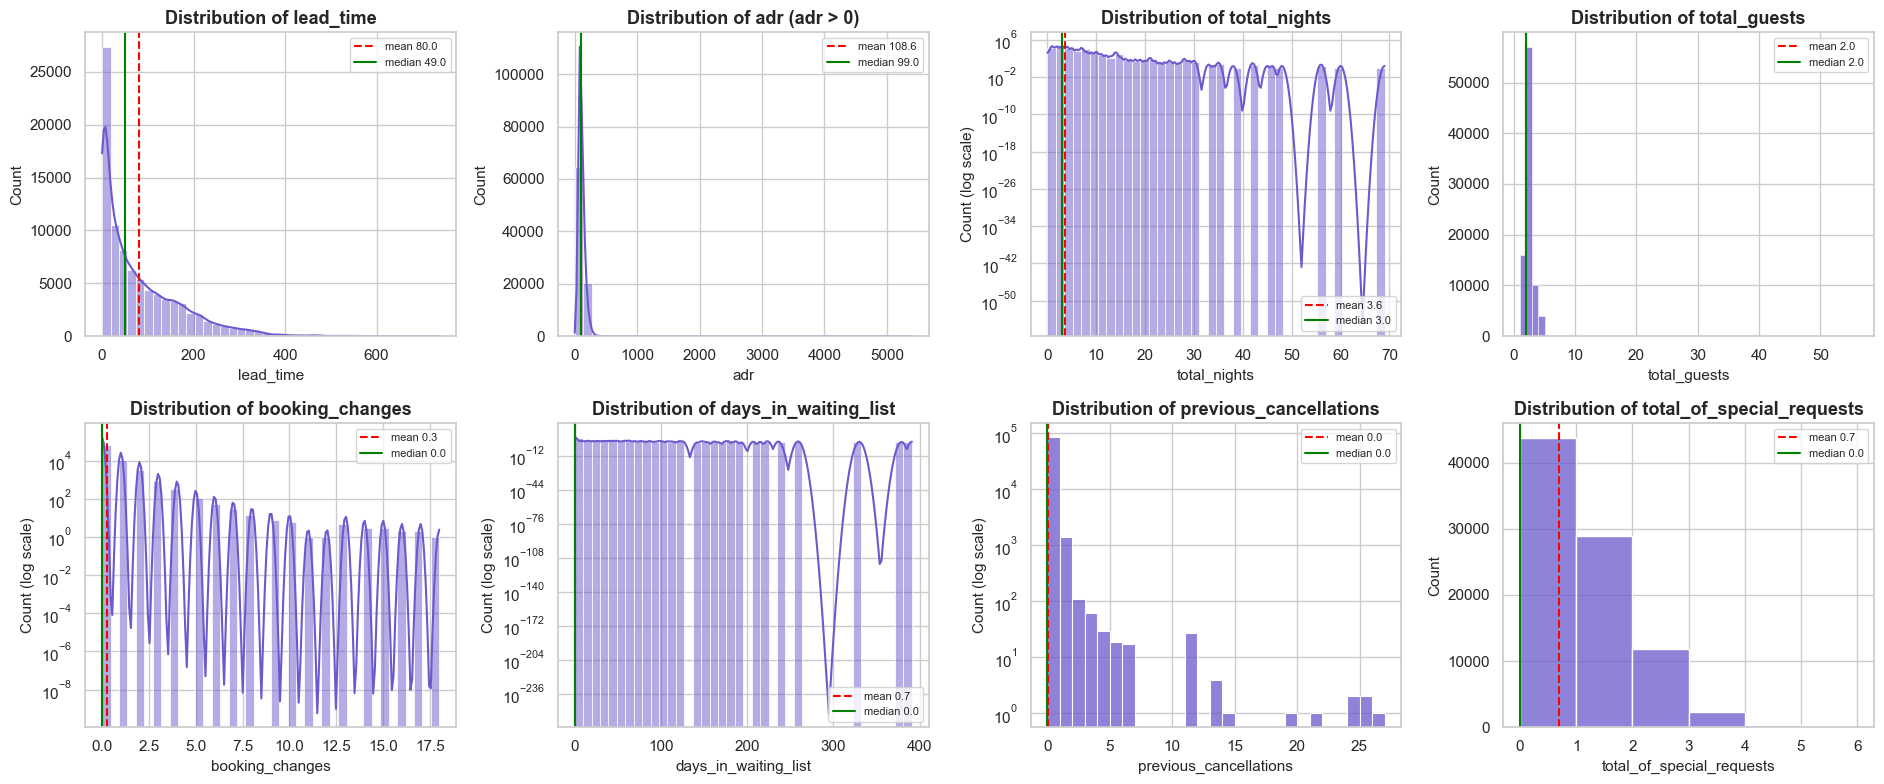

In [27]:
plot_cols = ["lead_time", "adr", "total_nights", "total_guests", "booking_changes", "days_in_waiting_list",
             "previous_cancellations", "total_of_special_requests"]
fig, axes = plt.subplots(2, 4, figsize=(19, 8))
for ax, c in zip(axes.ravel(), plot_cols):
    data = df.loc[df["adr"] > 0, c] if c == "adr" else df[c]
    discrete = data.nunique() <= 15
    sns.histplot(data, bins=range(int(data.min()), int(data.max()) + 2) if discrete else 40, ax=ax, color="slateblue", kde=not discrete)
    ax.axvline(data.mean(), color="red", ls="--", label=f"mean {data.mean():.1f}")
    ax.axvline(data.median(), color="green", ls="-", label=f"median {data.median():.1f}")
    ax.set_title(f"Distribution of {c}" + (" (adr > 0)" if c == "adr" else "")); ax.set_xlabel(c); ax.set_ylabel("Count"); ax.legend(fontsize=8)
    if c in ("total_nights", "booking_changes", "days_in_waiting_list", "previous_cancellations"): ax.set_yscale("log"); ax.set_ylabel("Count (log scale)")
plt.tight_layout(); plt.show()

**Observation:**
- **`lead_time`** is right-skewed (mean ≈ 80 days vs median 49): most guests book within two months, but a long tail books up to two years ahead.
- **`adr`** averages about €106 with a median near €98; the pre-cleaning mean/std are inflated by one extreme record (€5,400, handled in Section 9).
- **`total_nights`** has a median of 3 nights and ~94% of stays last a week or less.
- Most bookings are for **2 guests** (about 65%).
- Many count variables are **zero-inflated**: ~99% of bookings have no days on the waiting list or previous cancellations, ~92% have no parking request, ~90% have no children, and ~82% have no booking changes. These columns carry information only in their rare non-zero cases.
- Heavy skewness (lead time, nights, waiting list) suggests log transformation or tree-based models later.

## 9. Detect and Handle Outliers

**Step 1 — Visual detection (boxplots) and the IQR rule (Q1 − 1.5·IQR, Q3 + 1.5·IQR).**

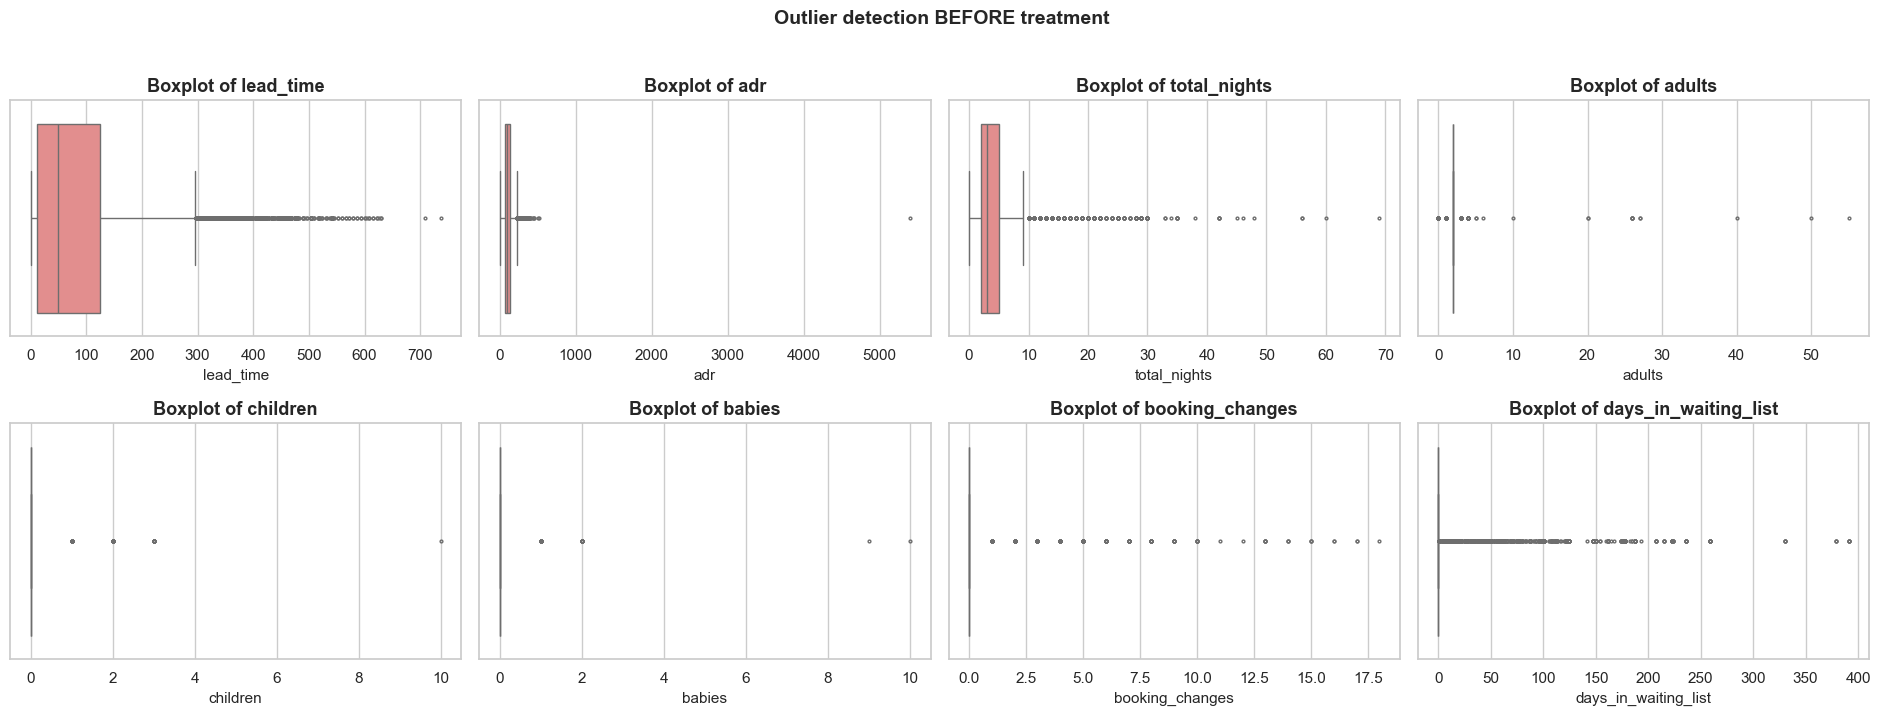

,lower_fence,upper_fence,max_value,n_outliers,outliers_%
feature,,,,,
lead_time,-160.00,296.00,737.00,2394,2.74
adr,-20.52,226.88,"5,400.00",2508,2.88
total_nights,-2.50,9.50,69.00,2990,3.43
adults,2.00,2.00,55.00,22733,26.06
children,0.00,0.00,10.00,8364,9.59
babies,0.00,0.00,10.00,914,1.05
booking_changes,0.00,0.00,18.00,15804,18.12
days_in_waiting_list,0.00,0.00,391.00,855,0.98


In [28]:
out_cols = ["lead_time", "adr", "total_nights", "adults", "children", "babies", "booking_changes", "days_in_waiting_list"]
fig, axes = plt.subplots(2, 4, figsize=(19, 7))
for ax, c in zip(axes.ravel(), out_cols):
    sns.boxplot(x=df[c], ax=ax, color="lightcoral", fliersize=2)
    ax.set_title(f"Boxplot of {c}"); ax.set_xlabel(c)
plt.suptitle("Outlier detection BEFORE treatment", y=1.02, fontsize=14, fontweight="bold")
plt.tight_layout(); plt.show()

def iqr_table(d, cols):
    rows = []
    for c in cols:
        q1, q3 = d[c].quantile([.25, .75]); iqr = q3 - q1
        lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
        n = int(((d[c] < lo) | (d[c] > hi)).sum())
        rows.append({"feature": c, "lower_fence": lo, "upper_fence": hi, "max_value": d[c].max(), "n_outliers": n, "outliers_%": n / len(d) * 100})
    return pd.DataFrame(rows).set_index("feature")

iqr_table(df, out_cols)

**Step 2 — Decide, feature by feature.** A statistical outlier is **not** automatically an error. Removing real but unusual behaviour would erase exactly the patterns we want to study, so each variable is judged on business logic:

| Feature | Verdict | Action |
|---|---|---|
| `lead_time` (up to ~700 days) | Real: some guests book almost 2 years ahead; skewed, not wrong | **Keep** (use log transform in modelling) |
| `adr` | One value of **5,400** per night versus a next-highest of ~510 — an isolated data-entry error | **Remove** values above 1,000 |
| `adults`, `children`, `babies` | Values like 20–55 adults or 9–10 babies in one booking are not credible (all are cancelled bookings with ADR = 0) | **Remove** adults ≥ 10, children ≥ 5, babies ≥ 5 |
| `total_nights`, `booking_changes`, `days_in_waiting_list` | Long stays, many amendments and long waiting lists happen in reality | **Keep** |

In [29]:
before = df.copy()
n0 = len(df)

mask_adr    = df["adr"] > 1000
mask_people = (df["adults"] >= 10) | (df["children"] >= 5) | (df["babies"] >= 5)
print(f"ADR > 1000                         : {mask_adr.sum()} row(s)")
print(f"Impossible party size              : {mask_people.sum()} row(s)")

df = df.loc[~(mask_adr | mask_people)].reset_index(drop=True)
log_step("Remove data-entry outliers (ADR > 1000, party size)", n0, len(df), "Isolated, implausible values; all other statistical outliers kept as genuine behaviour")
print(f"Rows: {n0:,} -> {len(df):,}  (removed {n0 - len(df)}, {(n0 - len(df)) / n0:.3%})")

ADR > 1000                         : 1 row(s)
Impossible party size              : 16 row(s)
Rows: 87,229 -> 87,212  (removed 17, 0.019%)


**Step 3 — Before vs after.**

before                           after                    
             count   mean   std      max     count   mean   std    max
adr      87,229.00 106.52 54.89 5,400.00 87,212.00 106.47 51.87 510.00
adults   87,229.00   1.88  0.62    55.00 87,212.00   1.88  0.50   6.00
children 87,229.00   0.14  0.46    10.00 87,212.00   0.14  0.46   3.00
babies   87,229.00   0.01  0.11    10.00 87,212.00   0.01  0.10   2.00

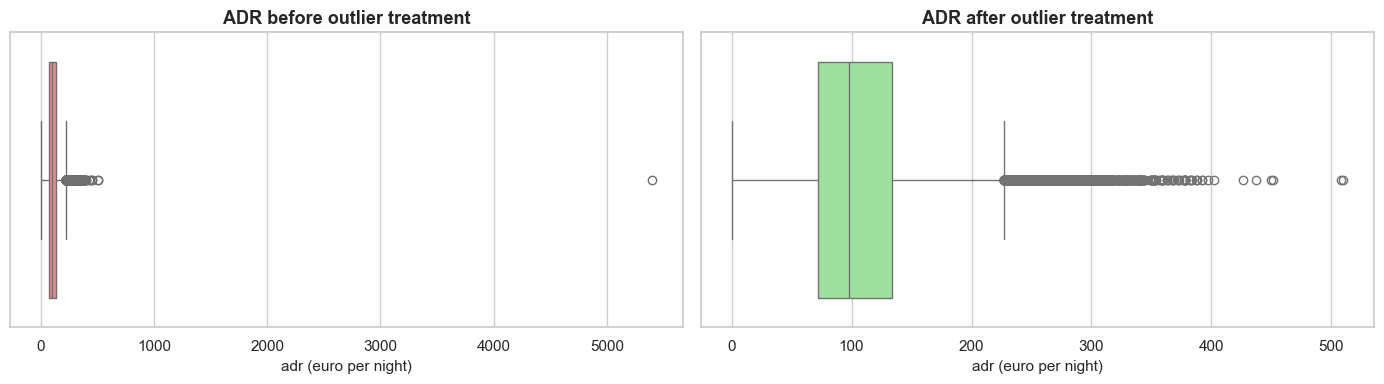

In [30]:
cmp_cols = ["adr", "adults", "children", "babies"]
comp = pd.concat({"before": before[cmp_cols].agg(["count", "mean", "std", "max"]).T,
                  "after":  df[cmp_cols].agg(["count", "mean", "std", "max"]).T}, axis=1)
display(comp)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.boxplot(x=before["adr"], ax=axes[0], color="lightcoral"); axes[0].set_title("ADR before outlier treatment"); axes[0].set_xlabel("adr (euro per night)")
sns.boxplot(x=df["adr"],     ax=axes[1], color="lightgreen"); axes[1].set_title("ADR after outlier treatment");  axes[1].set_xlabel("adr (euro per night)")
plt.tight_layout(); plt.show()

**Observation:**
- The IQR rule flags 2–3% of `lead_time`, `adr` and `total_nights`, but for discrete, zero-inflated columns (`adults`, `children`, `booking_changes`, `days_in_waiting_list`) the IQR is 0, so the rule flags thousands of perfectly normal rows (e.g. 26% of `adults`). The IQR rule alone would therefore have been **misleading**, which is why each variable was judged using business logic.
- Only **17 rows (0.02%)** were removed: one ADR of €5,400 (next highest €510) and 16 implausible party sizes (e.g. 55 adults or 10 babies; all cancelled with ADR = 0).
- **Before vs after:** the ADR maximum fell from 5,400 to 510 and its standard deviation from 54.9 to 51.9, while the mean barely moved (106.5 → 106.5); the maximum `adults` fell from 55 to 6. The treatment fixed the data-entry errors without distorting the genuine distribution.
- Long lead times, long stays and many booking changes were deliberately **kept** — they are real behaviour, and removing them would hide the very patterns linked to cancellation.

## 10. Perform Univariate Analysis

Each variable on its own: extremes, most common value and shape.

In [31]:
uni = df[num_cols].agg(["min", "max", "mean", "median", "skew"]).T
uni["most_common_value"] = [df[c].mode().iloc[0] for c in num_cols]
uni["share_of_most_common_%"] = [(df[c] == df[c].mode().iloc[0]).mean() * 100 for c in num_cols]
display(uni)

cat_summary = pd.DataFrame({
    "n_categories": [df[c].nunique() for c in cat_cols],
    "most_common": [df[c].mode().iloc[0] for c in cat_cols],
    "share_of_most_common_%": [df[c].value_counts(normalize=True).iloc[0] * 100 for c in cat_cols]}, index=cat_cols)
display(cat_summary)

,min,max,mean,median,skew,most_common_value,share_of_most_common_%
lead_time,0.00,737.00,79.93,49.00,1.43,0.00,6.77
adr,0.00,510.00,106.47,98.25,0.88,0.00,1.87
total_nights,0.00,69.00,3.63,3.00,2.95,3.00,20.44
total_guests,1.00,6.00,2.02,2.00,0.85,2.00,65.42
adults,0.00,6.00,1.88,2.00,-0.29,2.00,73.95
children,0.00,3.00,0.14,0.00,3.37,0.00,90.41
babies,0.00,2.00,0.01,0.00,10.00,0.00,98.95
booking_changes,0.00,18.00,0.27,0.00,5.07,0.00,81.88
days_in_waiting_list,0.00,391.00,0.75,0.00,19.47,0.00,99.02
previous_cancellations,0.00,26.00,0.03,0.00,34.33,0.00,98.07


,n_categories,most_common,share_of_most_common_%
hotel,2,City Hotel,61.08
market_segment,8,Online TA,59.11
distribution_channel,5,TA/TO,79.14
customer_type,4,Transient,82.40
deposit_type,3,No Deposit,98.69
meal,4,BB,77.85
reserved_room_type,9,A,64.70
country_grouped,17,PRT,31.35
agent_grouped,12,Agent 9,32.93
arrival_date_month,12,August,12.89


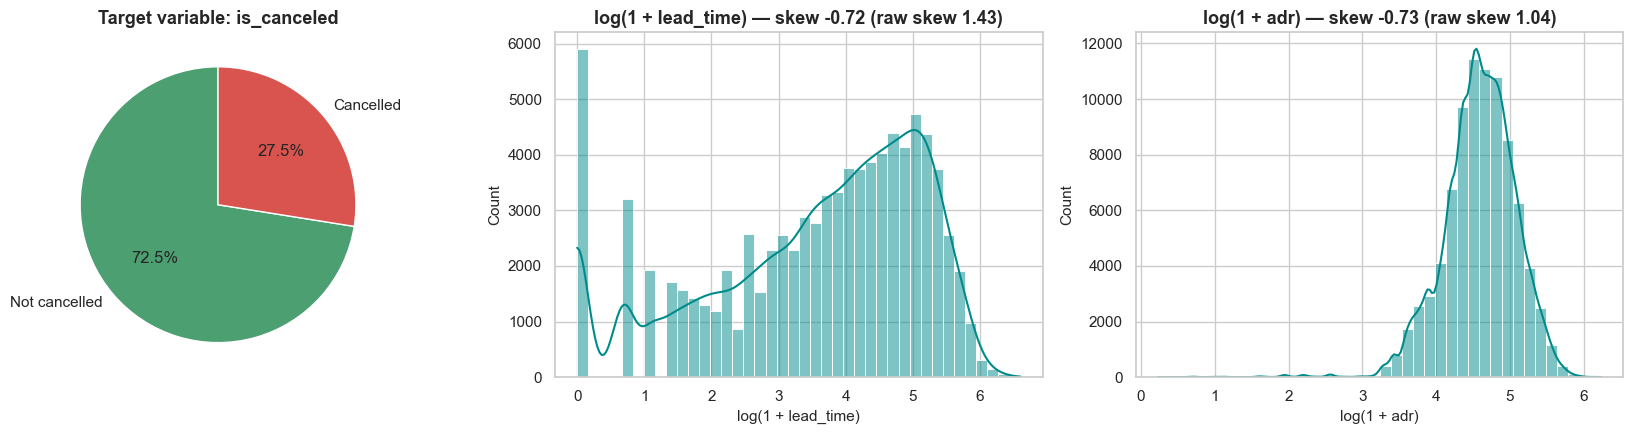

In [32]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))
t = df["is_canceled"].map({0: "Not cancelled", 1: "Cancelled"}).value_counts()
axes[0].pie(t, labels=t.index, autopct="%1.1f%%", colors=["#4c9f70", "#d9534f"], startangle=90)
axes[0].set_title("Target variable: is_canceled")
for ax, c in zip(axes[1:], ["lead_time", "adr"]):
    data = df.loc[df["adr"] > 0, c] if c == "adr" else df[c]
    sns.histplot(np.log1p(data), bins=40, kde=True, ax=ax, color="darkcyan")
    ax.set_title(f"log(1 + {c}) — skew {np.log1p(data).skew():.2f} (raw skew {data.skew():.2f})")
    ax.set_xlabel(f"log(1 + {c})"); ax.set_ylabel("Count")
plt.tight_layout(); plt.show()

**Observation:**
- **Target:** about 27.5% of bookings are cancelled — imbalanced but not extreme, so accuracy alone would be a poor metric for any future model.
- **Most common values:** the most frequent lead time is **0 days** (6.8% of bookings are same-day), the most common stay is 3 nights, and a party of 2 is the norm.
- **Extremes:** lead time reaches 737 days, total nights 69, ADR ranges up to €510 after cleaning.
- **Shape:** the log transform reduces the strong right skew (lead_time skew ≈ 1.43 → −0.72; adr ≈ 1.04 → −0.73) — useful for linear models, though it slightly over-corrects.
- Categorical variables are dominated by one category (e.g. 99% No Deposit, 82% Transient), meaning they will have limited discriminating power unless the minority groups behave very differently.

## 11. Perform Bivariate Analysis

### 11.1 Categorical vs cancellation — cancellation rate by group

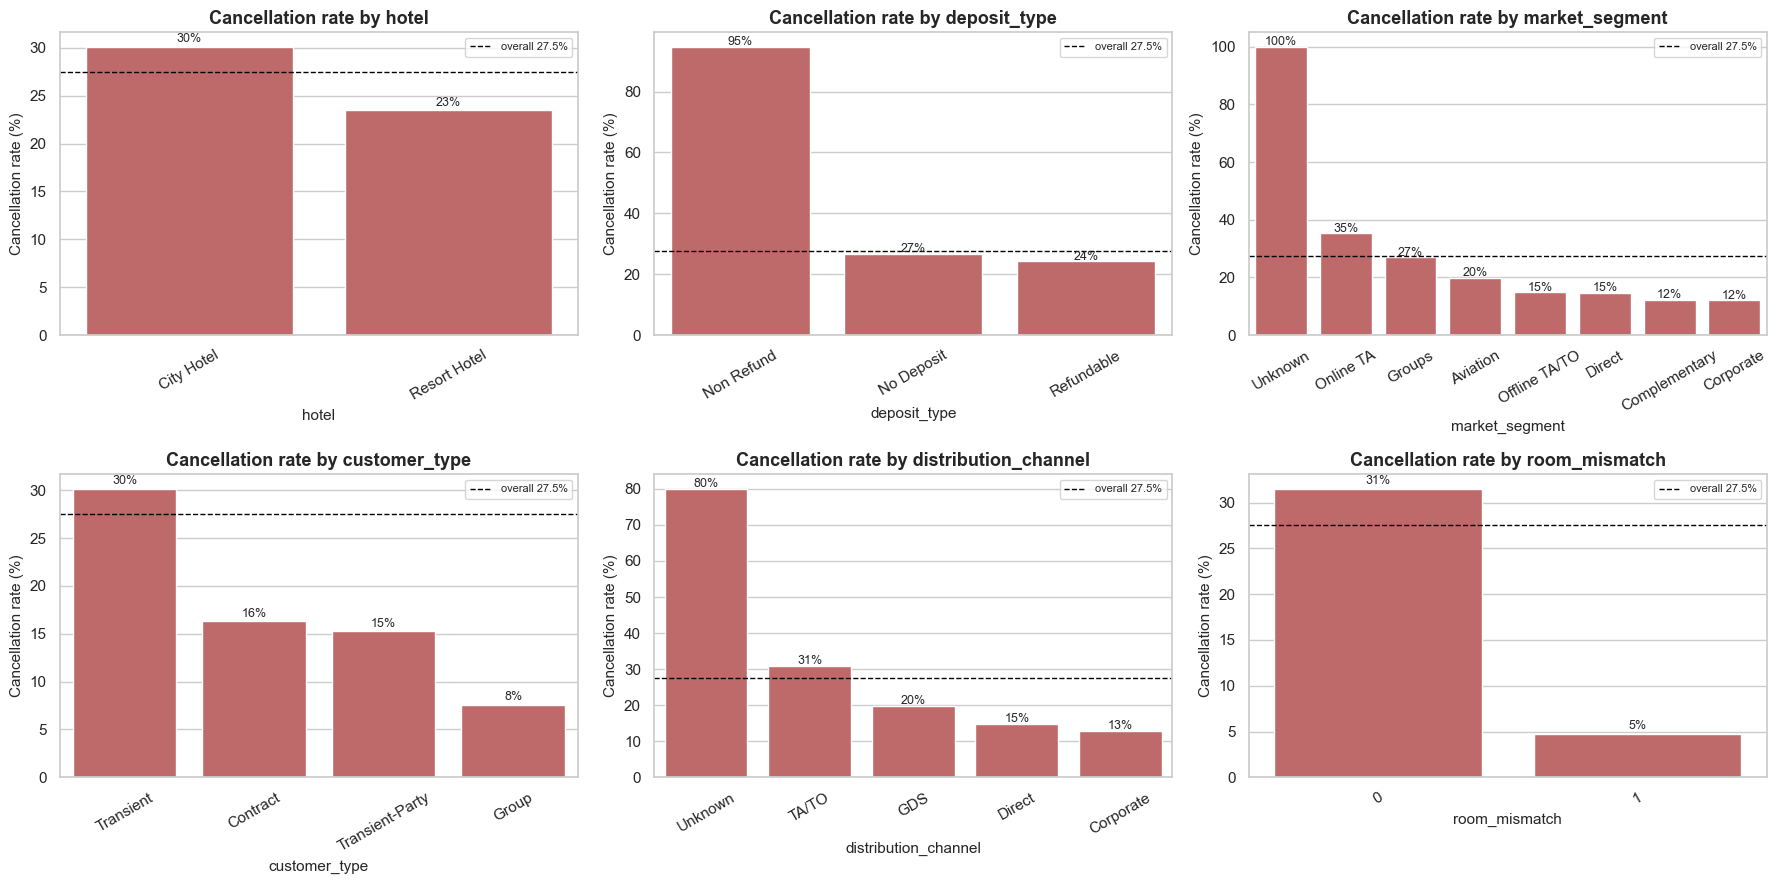

In [33]:
overall = df["is_canceled"].mean()
def cancel_rate_plot(ax, col, order=None):
    s = df.groupby(col, observed=True)["is_canceled"].mean().mul(100)
    s = s.reindex(order) if order is not None else s.sort_values(ascending=False)
    sns.barplot(x=s.index.astype(str), y=s.values, ax=ax, color="indianred")
    ax.axhline(overall * 100, color="black", ls="--", lw=1, label=f"overall {overall:.1%}")
    ax.set_title(f"Cancellation rate by {col}"); ax.set_xlabel(col); ax.set_ylabel("Cancellation rate (%)")
    ax.tick_params(axis="x", rotation=30); ax.legend(fontsize=8)
    for i, v in enumerate(s.values): ax.text(i, v + 0.5, f"{v:.0f}%", ha="center", fontsize=9)

fig, axes = plt.subplots(2, 3, figsize=(18, 9))
for ax, c in zip(axes.ravel(), ["hotel", "deposit_type", "market_segment", "customer_type", "distribution_channel", "room_mismatch"]):
    cancel_rate_plot(ax, c)
plt.tight_layout(); plt.show()

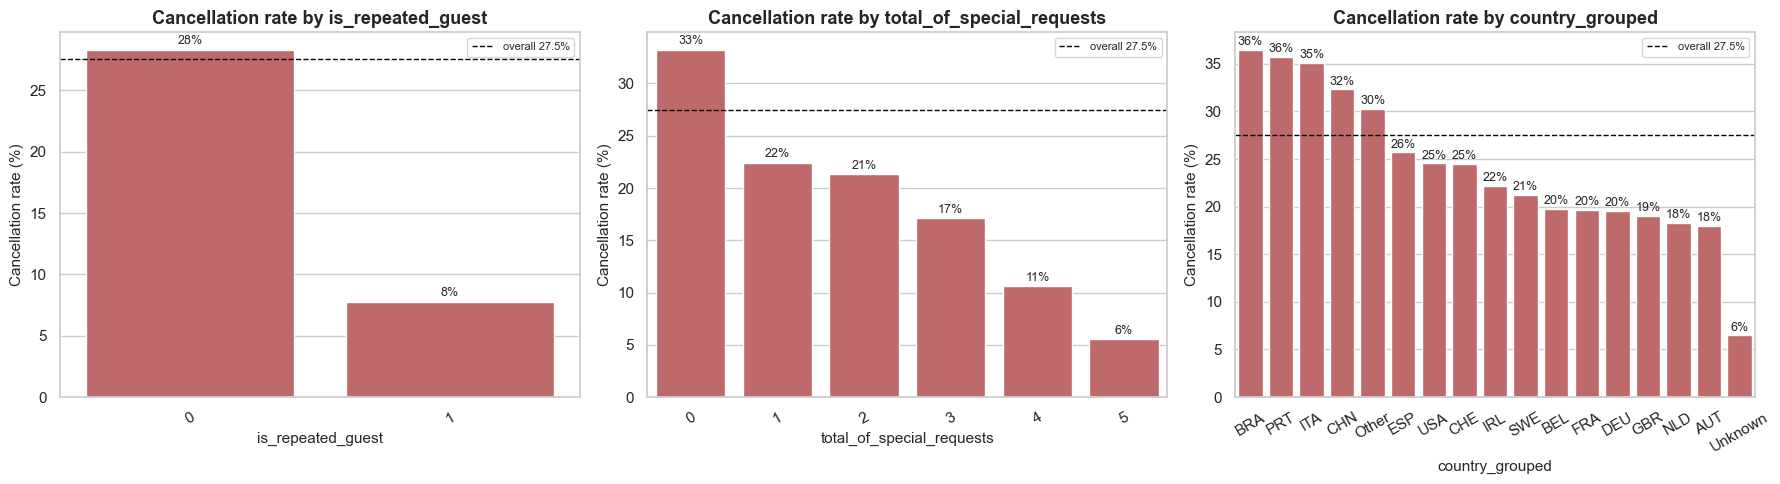

In [34]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
cancel_rate_plot(axes[0], "is_repeated_guest")
cancel_rate_plot(axes[1], "total_of_special_requests")
cancel_rate_plot(axes[2], "country_grouped")
plt.tight_layout(); plt.show()

### 11.2 Lead time vs cancellation (numerical vs categorical)

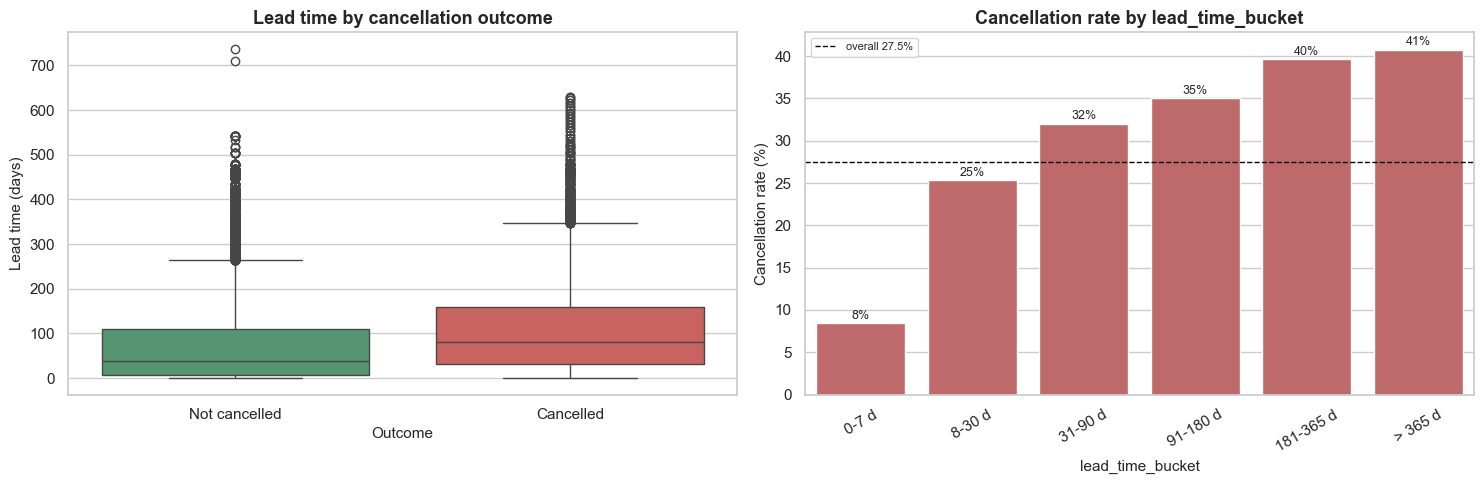

In [35]:
bins   = [-1, 7, 30, 90, 180, 365, 1000]
labels = ["0-7 d", "8-30 d", "31-90 d", "91-180 d", "181-365 d", "> 365 d"]
df["lead_time_bucket"] = pd.cut(df["lead_time"], bins=bins, labels=labels)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.boxplot(data=df, x="is_canceled", y="lead_time", ax=axes[0], palette=["#4c9f70", "#d9534f"], hue="is_canceled", legend=False)
axes[0].set_xticks([0, 1]); axes[0].set_xticklabels(["Not cancelled", "Cancelled"])
axes[0].set_title("Lead time by cancellation outcome"); axes[0].set_xlabel("Outcome"); axes[0].set_ylabel("Lead time (days)")
cancel_rate_plot(axes[1], "lead_time_bucket", order=labels)
plt.tight_layout(); plt.show()

### 11.3 Numerical vs numerical

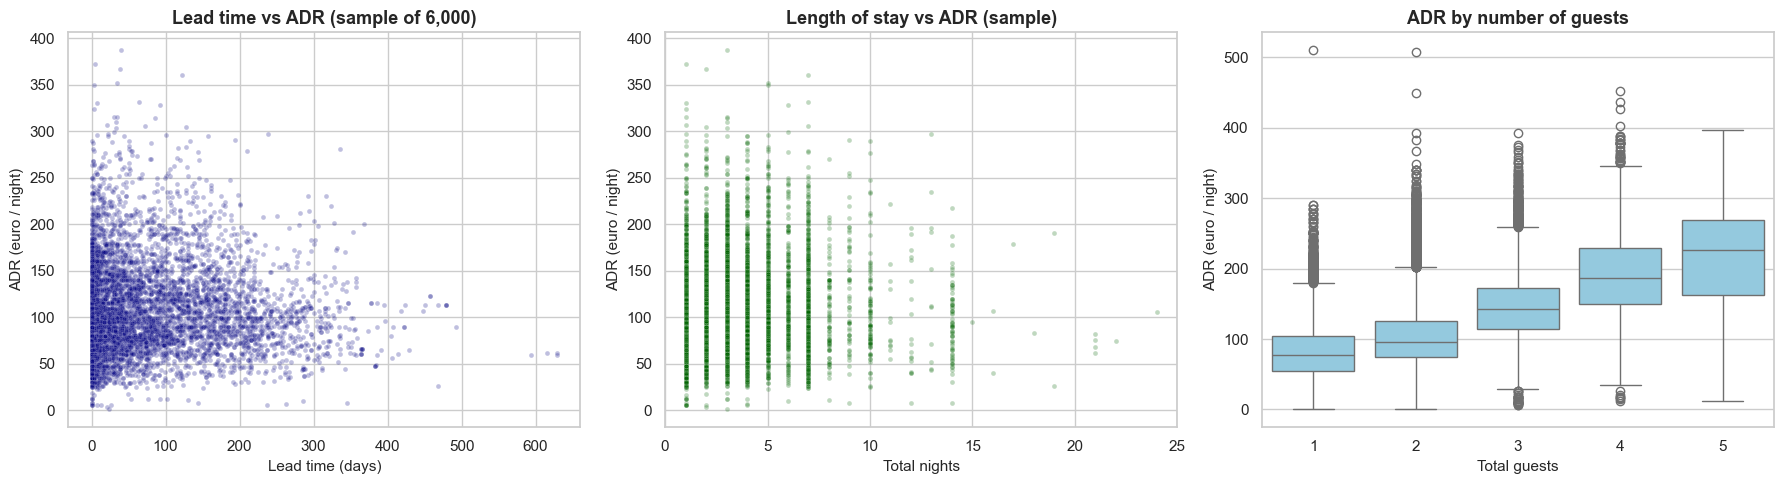

,spearman_rho
pair,
lead_time vs adr,0.11
total_nights vs adr,0.10
total_guests vs adr,0.42
lead_time vs total_nights,0.46


In [36]:
sample = df[df["adr"] > 0].sample(6000, random_state=RANDOM_STATE)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.scatterplot(data=sample, x="lead_time", y="adr", alpha=.25, s=12, ax=axes[0], color="navy")
axes[0].set_title("Lead time vs ADR (sample of 6,000)"); axes[0].set_xlabel("Lead time (days)"); axes[0].set_ylabel("ADR (euro / night)")
sns.scatterplot(data=sample, x="total_nights", y="adr", alpha=.25, s=12, ax=axes[1], color="darkgreen")
axes[1].set_title("Length of stay vs ADR (sample)"); axes[1].set_xlabel("Total nights"); axes[1].set_ylabel("ADR (euro / night)"); axes[1].set_xlim(0, 25)
sns.boxplot(data=df[df["adr"] > 0], x="total_guests", y="adr", ax=axes[2], color="skyblue")
axes[2].set_title("ADR by number of guests"); axes[2].set_xlabel("Total guests"); axes[2].set_ylabel("ADR (euro / night)")
plt.tight_layout(); plt.show()

pairs = [("lead_time", "adr"), ("total_nights", "adr"), ("total_guests", "adr"), ("lead_time", "total_nights")]
display(pd.DataFrame([{"pair": f"{a} vs {b}", "spearman_rho": stats.spearmanr(df[a], df[b])[0]} for a, b in pairs]).set_index("pair"))

### 11.4 Price (ADR) by category — seasonality and customer type

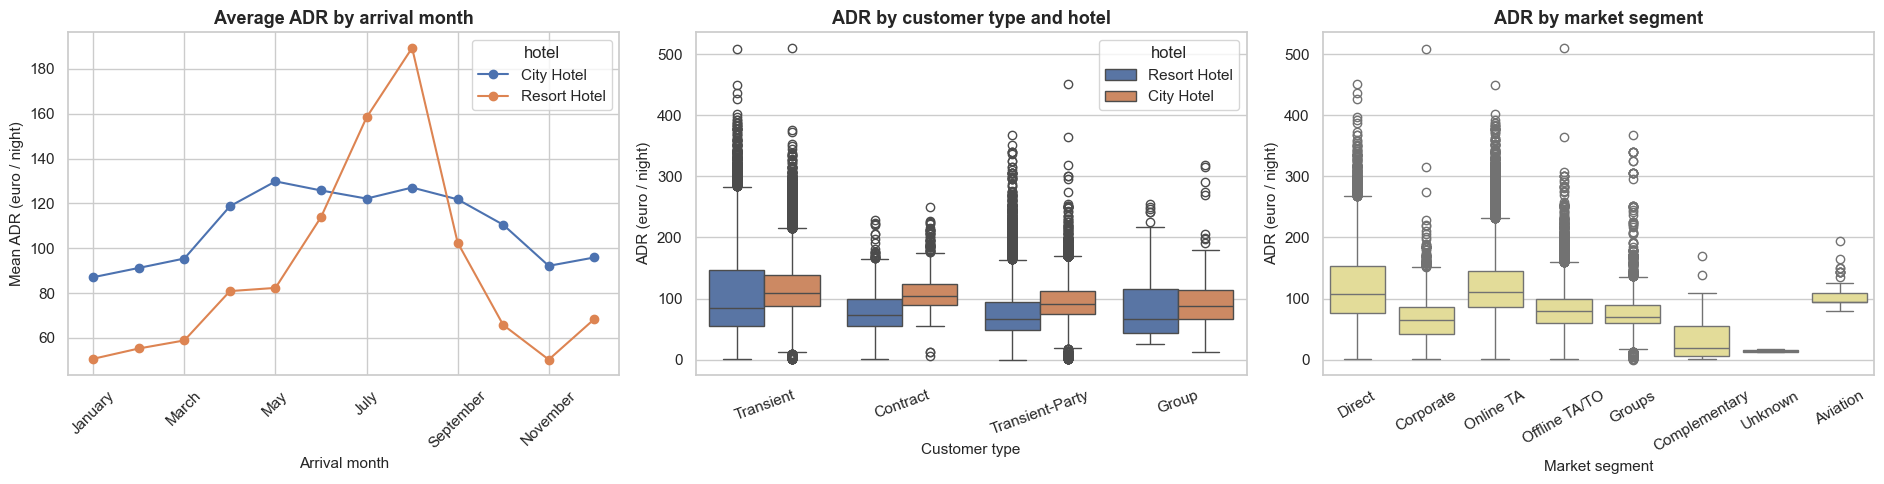

In [37]:
paid = df[df["adr"] > 0]
fig, axes = plt.subplots(1, 3, figsize=(19, 5))
monthly = paid.groupby(["arrival_date_month", "hotel"], observed=True)["adr"].mean().unstack()
monthly.plot(marker="o", ax=axes[0]); axes[0].set_title("Average ADR by arrival month"); axes[0].set_xlabel("Arrival month"); axes[0].set_ylabel("Mean ADR (euro / night)")
axes[0].tick_params(axis="x", rotation=45)
sns.boxplot(data=paid, x="customer_type", y="adr", hue="hotel", ax=axes[1]); axes[1].set_title("ADR by customer type and hotel"); axes[1].set_xlabel("Customer type"); axes[1].set_ylabel("ADR (euro / night)")
axes[1].tick_params(axis="x", rotation=20)
sns.boxplot(data=paid, x="market_segment", y="adr", ax=axes[2], color="khaki"); axes[2].set_title("ADR by market segment"); axes[2].set_xlabel("Market segment"); axes[2].set_ylabel("ADR (euro / night)")
axes[2].tick_params(axis="x", rotation=30)
plt.tight_layout(); plt.show()

### 11.5 Statistical strength of association with cancellation

In [38]:
def cramers_v(x, y):
    ct = pd.crosstab(x, y); chi2, p, _, _ = stats.chi2_contingency(ct)
    n = ct.values.sum(); k = min(ct.shape) - 1
    return np.sqrt(chi2 / (n * k)), p

cat_test = ["deposit_type", "market_segment", "country_grouped", "agent_grouped", "customer_type", "distribution_channel",
            "hotel", "reserved_room_type", "meal", "arrival_date_month", "room_mismatch", "is_repeated_guest"]
cv = pd.DataFrame([{"feature": c, "cramers_v": cramers_v(df[c], df["is_canceled"])[0], "p_value": cramers_v(df[c], df["is_canceled"])[1]} for c in cat_test])
display(cv.sort_values("cramers_v", ascending=False).set_index("feature"))

num_test = ["lead_time", "adr", "total_nights", "total_guests", "booking_changes", "days_in_waiting_list", "previous_cancellations",
            "previous_bookings_not_canceled", "required_car_parking_spaces", "total_of_special_requests"]
sp = pd.DataFrame([{"feature": c, "spearman_vs_cancel": stats.spearmanr(df[c], df["is_canceled"])[0]} for c in num_test])
display(sp.sort_values("spearman_vs_cancel", key=abs, ascending=False).set_index("feature"))

,cramers_v,p_value
feature,,
agent_grouped,0.27,0.00
market_segment,0.22,0.00
room_mismatch,0.21,0.00
deposit_type,0.17,0.00
country_grouped,0.16,0.00
distribution_channel,0.15,0.00
customer_type,0.13,0.00
is_repeated_guest,0.09,0.00
arrival_date_month,0.09,0.00


,spearman_vs_cancel
feature,
lead_time,0.23
required_car_parking_spaces,-0.19
adr,0.14
total_of_special_requests,-0.13
previous_cancellations,0.13
booking_changes,-0.12
total_nights,0.10
previous_bookings_not_canceled,-0.10
total_guests,0.10


**Observation:**
- **Lead time is the clearest behavioural driver.** Cancellation climbs steadily from **8.4%** for bookings made within a week to **40.8%** beyond a year; cancelled bookings have a median lead time of 80 days versus 38 for kept bookings.
- **Channel matters:** Online TA bookings cancel at **35%**, Groups 27%, while Direct and Offline TA/TO sit around 15% and Corporate is lowest at 12%. By customer type, Transient guests cancel ~30% versus 8% for Groups.
- **Hotel:** the City Hotel cancels more (30.1%) than the Resort (23.5%).
- **Non-refundable paradox:** 94.7% of Non Refund bookings are cancelled — see Insight 3.
- **Agents carry the strongest categorical association** (Cramér's V ≈ 0.27, followed by market segment 0.22): Agents 9 and 240 (together ~48% of all bookings) have cancel rates near 38–40%, versus 13% for bookings made with no agent.
- **Price:** ADR is only weakly related to lead time (ρ ≈ 0.11) and nights (ρ ≈ 0.10) but clearly related to **party size** (ρ ≈ 0.42), and it follows a strong seasonal curve — far higher in summer at the Resort.
- `room_mismatch` and parking look like strong predictors but are artefacts of check-in (see Insight 11).

## 12. Perform Multivariate Analysis

### 12.1 Correlation analysis and heatmap

### 12.2 Multi-variable patterns

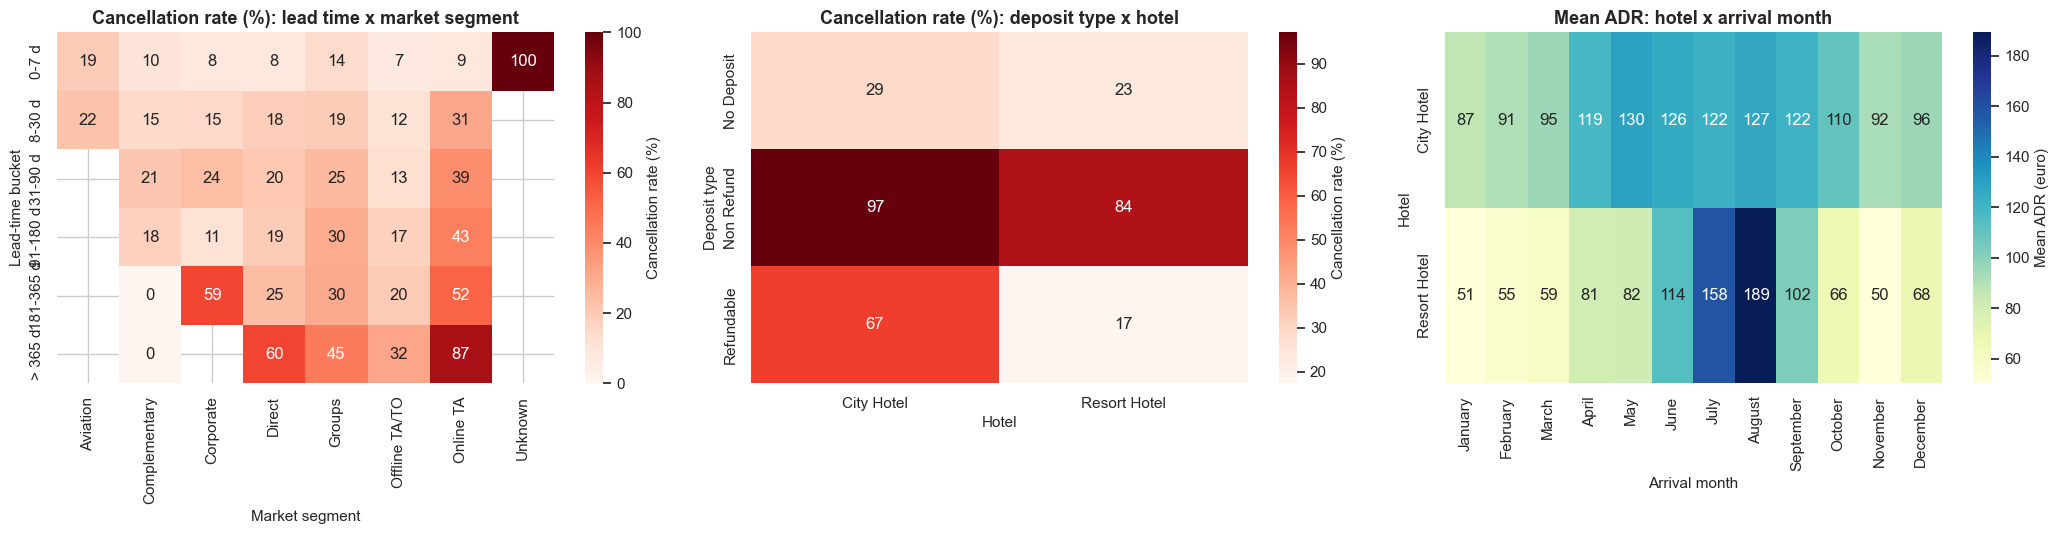

In [40]:
fig, axes = plt.subplots(1, 3, figsize=(21, 5.5))

t = df.pivot_table(index="lead_time_bucket", columns="market_segment", values="is_canceled", aggfunc="mean", observed=True) * 100
sns.heatmap(t, annot=True, fmt=".0f", cmap="Reds", ax=axes[0], cbar_kws={"label": "Cancellation rate (%)"})
axes[0].set_title("Cancellation rate (%): lead time x market segment"); axes[0].set_xlabel("Market segment"); axes[0].set_ylabel("Lead-time bucket")

t = df.pivot_table(index="deposit_type", columns="hotel", values="is_canceled", aggfunc="mean") * 100
sns.heatmap(t, annot=True, fmt=".0f", cmap="Reds", ax=axes[1], cbar_kws={"label": "Cancellation rate (%)"})
axes[1].set_title("Cancellation rate (%): deposit type x hotel"); axes[1].set_xlabel("Hotel"); axes[1].set_ylabel("Deposit type")

t = paid.pivot_table(index="hotel", columns="arrival_date_month", values="adr", aggfunc="mean", observed=True)
sns.heatmap(t, annot=True, fmt=".0f", cmap="YlGnBu", ax=axes[2], cbar_kws={"label": "Mean ADR (euro)"})
axes[2].set_title("Mean ADR: hotel x arrival month"); axes[2].set_xlabel("Arrival month"); axes[2].set_ylabel("Hotel")
plt.tight_layout(); plt.show()

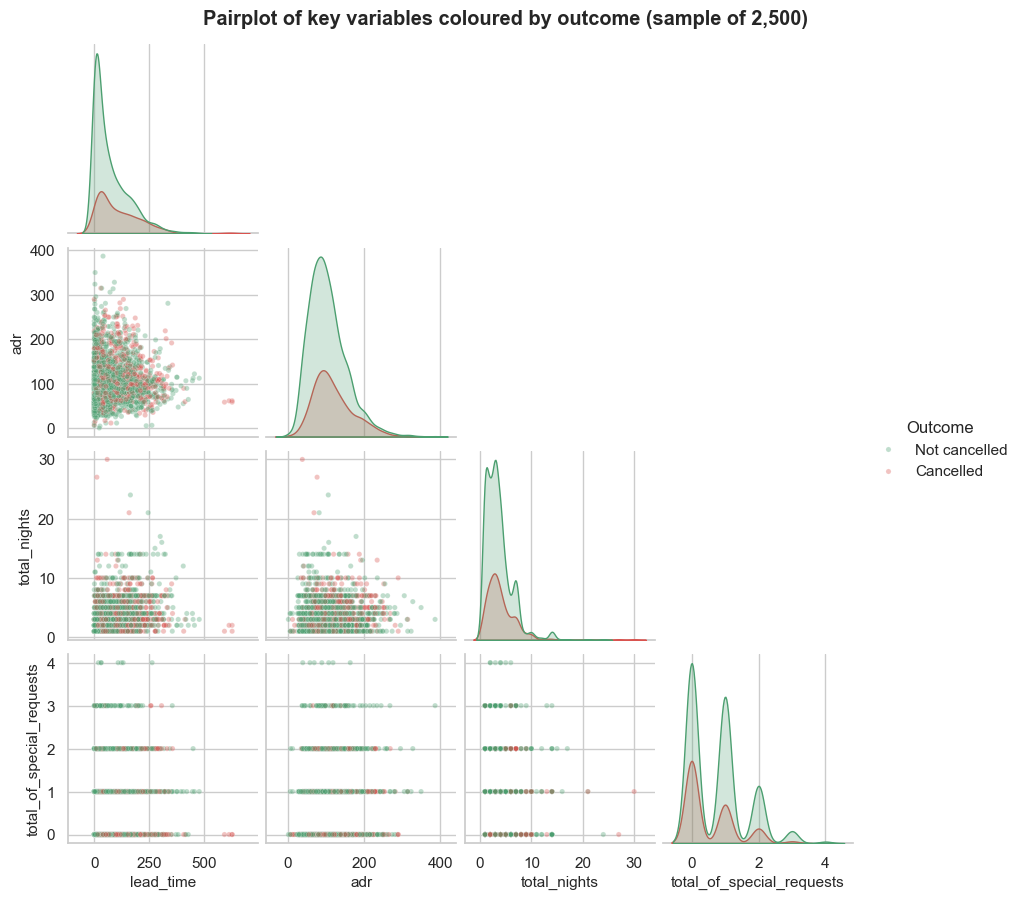

In [41]:
pp_cols = ["lead_time", "adr", "total_nights", "total_of_special_requests", "is_canceled"]
pp = df[df["adr"] > 0].sample(2500, random_state=RANDOM_STATE)[pp_cols].copy()
pp["Outcome"] = pp["is_canceled"].map({0: "Not cancelled", 1: "Cancelled"})
g = sns.pairplot(pp.drop(columns="is_canceled"), hue="Outcome", corner=True, plot_kws={"alpha": .35, "s": 14},
                 palette={"Not cancelled": "#4c9f70", "Cancelled": "#d9534f"}, height=2.2)
g.figure.suptitle("Pairplot of key variables coloured by outcome (sample of 2,500)", y=1.02, fontweight="bold"); plt.show()

### 12.3 Multicollinearity check (Variance Inflation Factor)

In [42]:
vif_cols = ["lead_time", "adr", "total_nights", "total_guests", "booking_changes", "total_of_special_requests",
            "previous_cancellations", "previous_bookings_not_canceled", "is_repeated_guest", "required_car_parking_spaces"]
R = np.corrcoef(df[vif_cols].values.T)
vif = pd.Series(np.diag(np.linalg.inv(R)), index=vif_cols, name="VIF").sort_values(ascending=False)
display(vif.to_frame())
print("Rule of thumb: VIF < 5 is fine, 5-10 moderate, > 10 serious multicollinearity.")

,VIF
previous_bookings_not_canceled,1.42
total_guests,1.34
is_repeated_guest,1.31
adr,1.31
previous_cancellations,1.19
lead_time,1.15
total_nights,1.13
total_of_special_requests,1.04
required_car_parking_spaces,1.02
booking_changes,1.01


Rule of thumb: VIF < 5 is fine, 5-10 moderate, > 10 serious multicollinearity.


**Observation:**
- **No feature is strongly correlated with cancellation**: the largest Spearman values are lead time (+0.23), parking (−0.19, suspect), ADR (+0.14), previous cancellations (+0.13) and special requests (−0.13). Cancellation is therefore driven by *combinations* of weak signals, not one dominant variable.
- The strongest feature-to-feature links are structural: `total_guests` ↔ `has_kids` (0.67), `is_repeated_guest` ↔ `previous_bookings_not_canceled` (0.80, Spearman), `total_guests` ↔ `adr` (0.42–0.47) and `lead_time` ↔ `total_nights` (0.32–0.46, longer stays are booked further ahead).
- **Interaction:** the first heatmap shows risk compounds — for **Online TA** bookings the cancellation rate rises from **9% (0–7 days) to 87% (> 365 days)**, far steeper than for most other segments.
- The second heatmap shows the deposit-type pattern holds in *both* hotels (Non Refund 97% City / 84% Resort), so it is not a single-hotel artefact.
- The ADR heatmap confirms the resort's strong summer peak versus the city hotel's flatter profile.
- **VIF values are all below 1.5**, so multicollinearity is not a concern for modelling.

## 13. Key Insights

Each insight below is computed directly from the cleaned data (so the numbers always match the analysis) and followed by **what it means**.

In [43]:
def pct(x): return f"{x:.1%}"
ins = []

removed_cancel_rate = (cancel_rate_raw * n_before - cancel_rate_dedup * n_after_dedup) / n_dups
ins.append(f"**1. Duplicates quietly distorted the target.** {n_dups:,} exact duplicate rows ({n_dups/n_before:.1%}) were removed; **{pct(removed_cancel_rate)}** of them were cancellations, so the overall cancellation rate moved from "
           f"**{pct(cancel_rate_raw)}** to **{pct(cancel_rate_dedup)}**. *Meaning:* duplicated records were disproportionately cancelled bookings; a model trained on the raw file would overestimate cancellation risk.")

ins.append("**2. `reservation_status` is a perfect leak.** It matches `is_canceled` exactly (Cancelled/No-Show = 1, Check-Out = 0). *Meaning:* it must never be used as a feature; "
           "otherwise a model reports near-perfect accuracy while learning nothing useful.")

dep = df.groupby("deposit_type")["is_canceled"].agg(["mean", "size"])
ins.append(f"**3. The 'Non Refund' paradox.** Non-refundable bookings cancel at **{pct(dep.loc['Non Refund','mean'])}** versus **{pct(dep.loc['No Deposit','mean'])}** for no-deposit bookings. "
           f"*Meaning:* this is the opposite of what a business rule would predict (guests lose money by cancelling). Only {int(dep.loc['Non Refund','size']):,} bookings carry this type, so it likely reflects how specific agents/segments "
           "recorded bookings rather than guest behaviour — a pattern to investigate, not to trust blindly.")

lt = df.groupby("lead_time_bucket", observed=True)["is_canceled"].mean()
ins.append(f"**4. Booking far ahead means higher risk.** Cancellation rises from **{pct(lt.iloc[0])}** for bookings made within a week to **{pct(lt.iloc[-1])}** for those made more than a year ahead "
           f"(Spearman ρ with the target = {stats.spearmanr(df['lead_time'], df['is_canceled'])[0]:.2f}). *Meaning:* lead time is the strongest behavioural early-warning signal available at booking time.")

sr = df.groupby(df["total_of_special_requests"] > 0)["is_canceled"].mean()
ins.append(f"**5. Engaged guests rarely cancel.** Guests with at least one special request cancel **{pct(sr[True])}** of the time versus **{pct(sr[False])}** without. "
           "*Meaning:* effort invested in a booking signals commitment, so the number of special requests is a cheap, useful risk feature.")

h = df.groupby("hotel")["is_canceled"].mean()
ms = df.groupby("market_segment")["is_canceled"].agg(["mean", "size"]); ms = ms[ms["size"] > 500]
ins.append(f"**6. Risk differs sharply by hotel and channel.** City Hotel cancels **{pct(h['City Hotel'])}** vs Resort Hotel **{pct(h['Resort Hotel'])}**; among segments with 500+ bookings, "
           f"**{ms['mean'].idxmax()}** is riskiest ({pct(ms['mean'].max())}) and **{ms['mean'].idxmin()}** safest ({pct(ms['mean'].min())}). *Meaning:* a one-size-fits-all overbooking policy would be wrong; it should be set per hotel and channel.")

pm = paid.groupby(["hotel", "arrival_date_month"], observed=True)["adr"].mean()
r_peak, r_low = pm["Resort Hotel"].idxmax(), pm["Resort Hotel"].idxmin()
c_peak, c_low = pm["City Hotel"].idxmax(), pm["City Hotel"].idxmin()
ins.append(f"**7. Price is strongly seasonal — and differently for each hotel.** Resort ADR peaks in **{r_peak}** (€{pm['Resort Hotel'].max():.0f}) and bottoms out in **{r_low}** (€{pm['Resort Hotel'].min():.0f}); "
           f"the City Hotel peaks in **{c_peak}** (€{pm['City Hotel'].max():.0f}) with a low in **{c_low}** (€{pm['City Hotel'].min():.0f}). *Meaning:* the resort is a leisure/summer product while the city hotel is steadier, so "
           "`arrival_date_month` (and hotel) are essential price predictors.")

top3 = df["country"].value_counts(normalize=True).head(3)
ins.append(f"**8. A home-market-driven guest base.** {top3.index[0]} alone accounts for **{pct(top3.iloc[0])}** of bookings, followed by {top3.index[1]} ({pct(top3.iloc[1])}) and {top3.index[2]} ({pct(top3.iloc[2])}); "
           f"{pct((df['customer_type']=='Transient').mean())} of bookings are 'Transient' and {pct((df['market_segment']=='Online TA').mean())} come through online travel agencies. *Meaning:* the hotels depend heavily on third-party platforms and one source market — a commercial concentration risk.")

rg = df.groupby("is_repeated_guest")["is_canceled"].mean()
ins.append(f"**9. Loyalty works, but it is rare.** Only **{pct(df['is_repeated_guest'].mean())}** of bookings are repeat guests, yet they cancel **{pct(rg[1])}** versus **{pct(rg[0])}** for first-timers. "
           "*Meaning:* growing the repeat-guest share is a low-risk revenue lever.")

ins.append(f"**10. The numeric features are largely independent.** The highest VIF is **{vif.iloc[0]:.2f}** ({vif.index[0]}), far below the usual threshold of 5. "
           f"*Meaning:* no serious multicollinearity — linear and tree models can both use these features without dropping variables.")

pk = df.groupby(df["required_car_parking_spaces"] > 0)["is_canceled"].mean()
rm = df.groupby("room_mismatch")["is_canceled"].mean()
ins.append(f"**11. Some strong signals are really 'after-the-fact' records.** Guests with a parking space cancel **{pct(pk[True])}** of the time, and bookings whose assigned room differs from the reserved room cancel only **{pct(rm[1])}** "
           f"(vs {pct(rm[0])} when rooms match). *Meaning:* rooms and parking are handled at check-in, so cancelled bookings never get them — these look predictive but would not be available when a booking is made. "
           "They are kept for analysis but excluded from the baseline model to avoid hidden leakage.")

display(Markdown("\n\n".join(ins)))

**1. Duplicates quietly distorted the target.** 31,994 exact duplicate rows (26.8%) were removed; **63.1%** of them were cancellations, so the overall cancellation rate moved from **37.0%** to **27.5%**. *Meaning:* duplicated records were disproportionately cancelled bookings; a model trained on the raw file would overestimate cancellation risk.

**2. `reservation_status` is a perfect leak.** It matches `is_canceled` exactly (Cancelled/No-Show = 1, Check-Out = 0). *Meaning:* it must never be used as a feature; otherwise a model reports near-perfect accuracy while learning nothing useful.

**3. The 'Non Refund' paradox.** Non-refundable bookings cancel at **94.7%** versus **26.7%** for no-deposit bookings. *Meaning:* this is the opposite of what a business rule would predict (guests lose money by cancelling). Only 1,037 bookings carry this type, so it likely reflects how specific agents/segments recorded bookings rather than guest behaviour — a pattern to investigate, not to trust blindly.

**4. Booking far ahead means higher risk.** Cancellation rises from **8.4%** for bookings made within a week to **40.8%** for those made more than a year ahead (Spearman ρ with the target = 0.23). *Meaning:* lead time is the strongest behavioural early-warning signal available at booking time.

**5. Engaged guests rarely cancel.** Guests with at least one special request cancel **21.7%** of the time versus **33.2%** without. *Meaning:* effort invested in a booking signals commitment, so the number of special requests is a cheap, useful risk feature.

**6. Risk differs sharply by hotel and channel.** City Hotel cancels **30.1%** vs Resort Hotel **23.5%**; among segments with 500+ bookings, **Online TA** is riskiest (35.4%) and **Corporate** safest (12.1%). *Meaning:* a one-size-fits-all overbooking policy would be wrong; it should be set per hotel and channel.

**7. Price is strongly seasonal — and differently for each hotel.** Resort ADR peaks in **August** (€189) and bottoms out in **November** (€50); the City Hotel peaks in **May** (€130) with a low in **January** (€87). *Meaning:* the resort is a leisure/summer product while the city hotel is steadier, so `arrival_date_month` (and hotel) are essential price predictors.

**8. A home-market-driven guest base.** PRT alone accounts for **31.3%** of bookings, followed by GBR (12.0%) and FRA (10.1%); 82.4% of bookings are 'Transient' and 59.1% come through online travel agencies. *Meaning:* the hotels depend heavily on third-party platforms and one source market — a commercial concentration risk.

**9. Loyalty works, but it is rare.** Only **3.9%** of bookings are repeat guests, yet they cancel **7.7%** versus **28.3%** for first-timers. *Meaning:* growing the repeat-guest share is a low-risk revenue lever.

**10. The numeric features are largely independent.** The highest VIF is **1.42** (previous_bookings_not_canceled), far below the usual threshold of 5. *Meaning:* no serious multicollinearity — linear and tree models can both use these features without dropping variables.

**11. Some strong signals are really 'after-the-fact' records.** Guests with a parking space cancel **0.0%** of the time, and bookings whose assigned room differs from the reserved room cancel only **4.7%** (vs 31.5% when rooms match). *Meaning:* rooms and parking are handled at check-in, so cancelled bookings never get them — these look predictive but would not be available when a booking is made. They are kept for analysis but excluded from the baseline model to avoid hidden leakage.

## 14. Final Conclusion

### 14.1 Readiness check for a future machine-learning project

To judge whether the cleaned data is *usable*, a quick **baseline model** predicts `is_canceled` using only information available at booking time. To mimic real deployment, the split is **chronological**: train on arrivals before 2017, test on 2017 arrivals. This is a feasibility test, not a tuned model.

Train: 55,580 rows (arrivals before 2017) | Test: 31,632 rows (2017 arrivals) | 96 features


,Majority-class baseline,Random Forest
Accuracy,0.68,0.76
Precision,NaN,0.72
Recall,NaN,0.41
ROC-AUC,0.50,0.83
F1,NaN,0.52


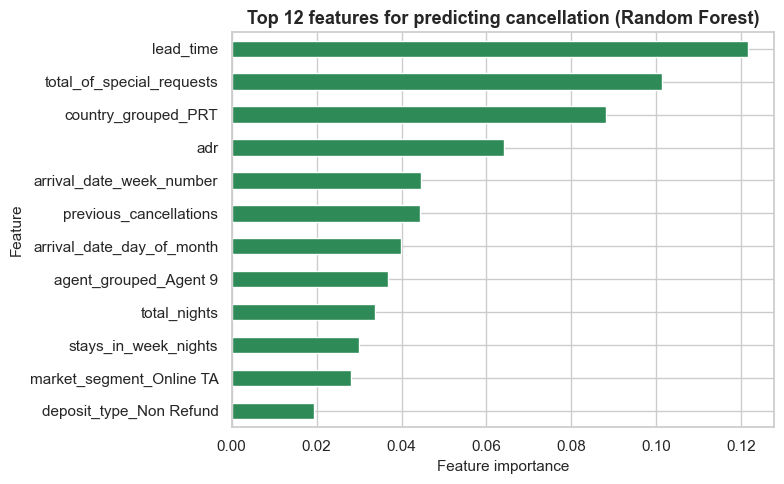

In [44]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.dummy import DummyClassifier
from sklearn.metrics import roc_auc_score, f1_score, accuracy_score, precision_score, recall_score

cat_feats = ["hotel", "meal", "country_grouped", "market_segment", "distribution_channel", "reserved_room_type",
             "deposit_type", "customer_type", "agent_grouped", "arrival_date_month"]
num_feats = ["lead_time", "arrival_date_week_number", "arrival_date_day_of_month", "stays_in_weekend_nights", "stays_in_week_nights",
             "adults", "children", "babies", "is_repeated_guest", "previous_cancellations", "previous_bookings_not_canceled",
             "booking_changes", "days_in_waiting_list", "adr", "total_of_special_requests",
             "total_nights", "total_guests", "has_kids", "has_agent", "has_company"]

X = pd.get_dummies(df[cat_feats + num_feats].assign(arrival_date_month=df["arrival_date_month"].astype(str)), columns=cat_feats, dtype=int)
y = df["is_canceled"]
train = df["arrival_date"] < "2017-01-01"
X_tr, X_te, y_tr, y_te = X[train], X[~train], y[train], y[~train]
print(f"Train: {len(X_tr):,} rows (arrivals before 2017) | Test: {len(X_te):,} rows (2017 arrivals) | {X.shape[1]} features")

dummy = DummyClassifier(strategy="most_frequent").fit(X_tr, y_tr)
rf = RandomForestClassifier(n_estimators=200, min_samples_leaf=3, n_jobs=-1, random_state=RANDOM_STATE).fit(X_tr, y_tr)
proba = rf.predict_proba(X_te)[:, 1]; pred = (proba >= .5).astype(int)

results = pd.DataFrame({
    "Majority-class baseline": [accuracy_score(y_te, dummy.predict(X_te)), np.nan, np.nan, 0.5, np.nan],
    "Random Forest": [accuracy_score(y_te, pred), precision_score(y_te, pred), recall_score(y_te, pred), roc_auc_score(y_te, proba), f1_score(y_te, pred)]},
    index=["Accuracy", "Precision", "Recall", "ROC-AUC", "F1"])
display(results)

imp = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False).head(12)
ax = imp.sort_values().plot(kind="barh", figsize=(8, 5), color="seagreen")
ax.set_title("Top 12 features for predicting cancellation (Random Forest)"); ax.set_xlabel("Feature importance"); ax.set_ylabel("Feature")
plt.tight_layout(); plt.show()

**Observation:** Using only booking-time information and a **chronological** split, a basic Random Forest reaches **ROC-AUC ≈ 0.83** and **accuracy ≈ 0.76** against a 0.68 majority-class baseline, with precision ≈ 0.72 but recall ≈ 0.41 at the default 0.5 threshold. The most useful features are lead time, special requests, guest country (Portugal), ADR, arrival week and previous cancellations — consistent with the EDA findings.

This proves the cleaned data contains real predictive signal. The modest recall also shows what is left to do: threshold tuning, class weighting and better features. Note the test set (2017) has a higher cancellation rate than the training years (cancellation rose from about 20% in 2015 to 32% in 2017), a sign of **concept drift** that a real project would need to monitor.

### 14.2 Summary of findings

**What I learned.** The dataset covers ~119k reservations from a city and a resort hotel in Portugal. After cleaning it holds **87,212 reliable bookings** with a **27.5% cancellation rate**. Cancellations depend mostly on *when* and *how* a guest books — long lead times, online travel agents and specific agents are high risk, while special requests, repeat guests and corporate/direct bookings are low risk. Price is driven mainly by hotel, season and party size.

**Important patterns.**
1. Cancellation risk grows with lead time, and compounds sharply for Online TA bookings (9% → 87%).
2. Prices are highly seasonal; the Resort Hotel swings from about €50 in November to about €189 in August, while the City Hotel is steadier.
3. The guest base is concentrated: Portugal ≈ 31% of bookings, Online TA ≈ 59%, Transient guests ≈ 82%.
4. Repeat guests are rare (3.9%) but far more reliable (7.7% cancellation vs 28.3%).

**Data-quality problems found.**
- 26.8% exact duplicates that inflated the cancellation rate from 27.5% to 37.0%.
- Target leakage (`reservation_status`, `reservation_status_date`) that would give a perfect but meaningless model.
- Hidden missing values (`Undefined`, `agent`/`company` NULLs), inconsistent country codes (`CN`/`CHN`), 167 impossible records and 17 data-entry outliers (ADR 5,400; 55 adults).
- Features that look predictive but are only recorded at check-in (`assigned_room_type`/`room_mismatch`, parking) and a suspicious Non Refund pattern.

**Use for machine learning.** `df_clean` is ready for (a) a **cancellation classifier** (`is_canceled`, with class-imbalance handling and ROC-AUC / recall as metrics) and (b) an **ADR regression** model (using `adr > 0`, log-transformed target, hotel × month interactions). Recommended next steps: a time-based validation scheme, threshold tuning, target/frequency encoding for `country` and `agent`, log transforms for skewed counts, careful review of `booking_changes` and `days_in_waiting_list` for leakage, and monitoring for drift because cancellation rates rose over the three years.

### 14.3 Final cleaned DataFrame

In [45]:
df_clean = df.drop(columns=["cancel_notice_days", "lead_time_bucket"]).reset_index(drop=True)

assert df_clean.isna().sum().sum() == 0,          "missing values remain"
assert (df_clean["adr"] >= 0).all(),              "negative ADR remains"
assert (df_clean["total_guests"] > 0).all(),      "zero-guest bookings remain"
assert not {"reservation_status", "reservation_status_date"} & set(df_clean.columns), "leakage columns remain"
print("All validation checks passed ✔")

n_lookalike = int(df_clean.duplicated().sum())
print(f"Note: {n_lookalike:,} rows ({n_lookalike/len(df_clean):.1%}) share identical booking features with another row but were distinct in the raw data -> kept.")

from pathlib import Path
saved_to = None
for target in [Path("hotel_bookings_cleaned.csv"), Path("hotel_bookings_cleaned_v2.csv"), Path.home() / "hotel_bookings_cleaned.csv"]:
    try:
        df_clean.to_csv(target, index=False)
        saved_to = target
        break
    except OSError:
        print(f"Cannot write to '{target}' (file open in Excel or folder is read-only) - trying another location...")

print(f"df_clean: {df_clean.shape[0]:,} rows x {df_clean.shape[1]} columns  |  raw file: {df_raw.shape[0]:,} rows x {df_raw.shape[1]} columns")
print(f"Saved -> {saved_to.resolve()}" if saved_to else "CSV could not be saved (check folder permissions); df_clean is still available in memory.")
display(df_clean.head())
df_clean.info()

All validation checks passed ✔
Note: 271 rows (0.3%) share identical booking features with another row but were distinct in the raw data -> kept.
Cannot write to 'hotel_bookings_cleaned.csv' (file open in Excel or folder is read-only) - trying another location...
df_clean: 87,212 rows x 37 columns  |  raw file: 119,390 rows x 32 columns
Saved -> C:\Users\dsawa\Desktop\unlox\hotel_bookings_cleaned_v2.csv


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,has_company,has_agent,arrival_date,total_nights,total_guests,has_kids,room_mismatch,country_grouped,agent_grouped
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,0,0,BB,PRT,Direct,Direct,0,0,0,C,C,3,No Deposit,0,Transient,0.00,0,0,0,0,2015-07-01,0,2,0,0,PRT,No Agent
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,0,0,BB,PRT,Direct,Direct,0,0,0,C,C,4,No Deposit,0,Transient,0.00,0,0,0,0,2015-07-01,0,2,0,0,PRT,No Agent
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,0,0,BB,GBR,Direct,Direct,0,0,0,A,C,0,No Deposit,0,Transient,75.00,0,0,0,0,2015-07-01,1,1,0,1,GBR,No Agent
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,0,0,BB,GBR,Corporate,Corporate,0,0,0,A,A,0,No Deposit,0,Transient,75.00,0,0,0,1,2015-07-01,1,1,0,0,GBR,Other Agents
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,0,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,0,Transient,98.00,0,1,0,1,2015-07-01,2,2,0,0,GBR,Agent 240


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 87212 entries, 0 to 87211
Data columns (total 37 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   hotel                           87212 non-null  object        
 1   is_canceled                     87212 non-null  int64         
 2   lead_time                       87212 non-null  int64         
 3   arrival_date_year               87212 non-null  int64         
 4   arrival_date_month              87212 non-null  category      
 5   arrival_date_week_number        87212 non-null  int64         
 6   arrival_date_day_of_month       87212 non-null  int64         
 7   stays_in_weekend_nights         87212 non-null  int64         
 8   stays_in_week_nights            87212 non-null  int64         
 9   adults                          87212 non-null  int64         
 10  children                        87212 non-null  int64         
 11  ba